## Section 0: Configuration & Constants

In [1]:
# ============================================================================
# SECTION 0: CONFIGURATION & CONSTANTS
# ============================================================================

RANDOM_SEED = 231

NUM_CLASSES = 4
PARTICLE_NAMES = ['Pion', 'Kaon', 'Proton', 'Electron']
PDG_TO_SPECIES = {
    211: 0,
    321: 1,
    2212: 2,
    11: 3,
}

MOMENTUM_RANGES = [
    {'key': 'full',   'name': 'Full Spectrum (0.1-∞ GeV/c)', 'min': 0.1, 'max': float('inf'),  'apply_dpg_cuts': False},
    {'key': '0.1-1',  'name': '0-1 GeV/c',                   'min': 0.1, 'max': 1.0,           'apply_dpg_cuts': False},
    {'key': '0.7-1.5','name': '0.7-1.5 GeV/c',               'min': 0.7, 'max': 1.5,           'apply_dpg_cuts': False},
    {'key': '1-3',    'name': '1-3 GeV/c',                   'min': 1.0, 'max': 3.0,           'apply_dpg_cuts': False},

    # Momentum ranges with DPG recommended cuts & track selections
    {'key': 'full_DPG',   'name': 'Full Spectrum (0.1-∞ GeV/c, DPG cuts)', 'min': 0.1, 'max': float('inf'),  'apply_dpg_cuts': True},
    {'key': '0.1-1_DPG',  'name': '0-1 GeV/c (DPG cuts)',                   'min': 0.1, 'max': 1.0,          'apply_dpg_cuts': True},
    {'key': '0.7-1.5_DPG','name': '0.7-1.5 GeV/c (DPG cuts)',               'min': 0.7, 'max': 1.5,          'apply_dpg_cuts': True},
    {'key': '1-3_DPG',    'name': '1-3 GeV/c (DPG cuts)',                   'min': 1.0, 'max': 3.0,          'apply_dpg_cuts': True},
]

# ============================================================================
# DPG-RECOMMENDED TRACK SELECTIONS (Nov 2025)
# NOTE: pT / p ranges applied separately via MOMENTUM_RANGES
# ============================================================================
TRACK_SELECTIONS = {
    'event': {'vz_max': 10.0},            # |vZ| < 10 cm
    'kinematics': {'eta_min': -0.8, 'eta_max': 0.8},
    'dca': {'dca_xy_max': 0.105, 'dca_z_max': 0.12},
    'tpc': {'tpc_clusters_min': 70},
    'its': {'its_clusters_min': 3},       # ITS currently not used
}

TRACK_QUALITY_FILTER = {
    'tpc_clusters_min': 70,       # Remove low-quality tracks (38% have <70)
    'momentum_min': 0.01,         # No unphysical momenta
    'remove_negative_chi2': True, # File 005 had corrupted chi2 values
}


CSV_PATH = '/kaggle/input/datasets/robertforynski/new-ao2d-lhc25f60544122/pid_features_*.csv'
# CSV_PATH = '/kaggle/input/datasets/robertforynski/new-ao2d-lhc25f60544122/pid_features_00[89].csv'

TRAINING_FEATURES = [
    'pt', 'eta', 'phi',
    'tpc_signal', 'tpc_nsigma_pi', 'tpc_nsigma_ka', 'tpc_nsigma_pr', 'tpc_nsigma_el',
    'tof_beta', 'tof_nsigma_pi', 'tof_nsigma_ka', 'tof_nsigma_pr', 'tof_nsigma_el',
    'bayes_prob_pi', 'bayes_prob_ka', 'bayes_prob_pr', 'bayes_prob_el',
    'dca_xy', 'dca_z',
    'has_tpc', 'has_tof',
]

DETECTOR_GROUPS = {
    'tpc': ['tpc_signal', 'tpc_nsigma_pi', 'tpc_nsigma_ka', 'tpc_nsigma_pr', 'tpc_nsigma_el'],
    'tof': ['tof_beta', 'tof_nsigma_pi', 'tof_nsigma_ka', 'tof_nsigma_pr', 'tof_nsigma_el'],
    'bayes': ['bayes_prob_pi', 'bayes_prob_ka', 'bayes_prob_pr', 'bayes_prob_el'],
    'kinematics': ['pt', 'eta', 'phi', 'dca_xy', 'dca_z'],
}

MODEL_TYPES = [
    'JAX_SimpleNN',
    'JAX_DNN',
    'JAX_FSE_Attention',
    'RandomForest',
    'LightGBM',
    'XGBoost'
]

HYPERPARAMETERS = {
    'JAX_SimpleNN': {
        'hidden_dims': [512, 256, 128, 64],
        'dropout_rate': 0.5,
        'learning_rate': 1e-4,
        'batch_size': 256,
        'num_epochs': 100,
        'patience': 30,
    },
    'JAX_DNN': {
        'hidden_dims': [1024, 512, 256, 128, 64],
        'dropout_rate': 0.5,
        'learning_rate': 5e-5,
        'batch_size': 256,
        'num_epochs': 100,
        'patience': 30,
    },
    'JAX_FSE_Attention': {
        'hidden_dim': 64,
        'num_heads': 4,
        'dropout_rate': 0.5,
        'learning_rate': 1e-4,
        'batch_size': 256,
        'num_epochs': 100,
        'patience': 30,
    },
    'RandomForest': {
        'n_estimators': 300,
        'max_depth': 20,
        'min_samples_split': 5,
        'n_jobs': -1,
        'random_state': 42
    },
    'LightGBM': {
        'n_estimators': 500,
        'learning_rate': 0.05,
        'num_leaves': 64,
        'max_depth': -1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': RANDOM_SEED,
        'n_jobs': -1
    },
    'XGBoost': {
        'n_estimators': 500,
        'learning_rate': 0.05,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'tree_method': 'hist',
        'random_state': RANDOM_SEED,
        'n_jobs': -1
    },
}

FORCE_TRAINING = {
    'JAX_SimpleNN': {
        'full': False, '0.7-1.5': False, '0.1-1': False, '1-3': False,
        'full_DPG': False, '0.7-1.5_DPG': False, '0.1-1_DPG': False, '1-3_DPG': False,
    },
    'JAX_DNN': {
        'full': False, '0.7-1.5': False, '0.1-1': False, '1-3': False,
        'full_DPG': False, '0.7-1.5_DPG': False, '0.1-1_DPG': False, '1-3_DPG': False,
    },
    'JAX_FSE_Attention': {
        'full': False, '0.7-1.5': False, '0.1-1': False, '1-3': False,
        'full_DPG': False, '0.7-1.5_DPG': False, '0.1-1_DPG': False, '1-3_DPG': False,
    },
    'RandomForest': {
        'full': True, '0.7-1.5': True, '0.1-1': True, '1-3': True,
        'full_DPG': True, '0.7-1.5_DPG': True, '0.1-1_DPG': True, '1-3_DPG': True,
    },
    'LightGBM': {
        'full': True, '0.7-1.5': True, '0.1-1': True, '1-3': True,
        'full_DPG': True, '0.7-1.5_DPG': True, '0.1-1_DPG': True, '1-3_DPG': True,
    },
    'XGBoost': {
        'full': True, '0.7-1.5': True, '0.1-1': True, '1-3': True,
        'full_DPG': True, '0.7-1.5_DPG': True, '0.1-1_DPG': True, '1-3_DPG': True,
    },
}


model_colors = {
    'JAX_SimpleNN': '#3B82F6',                     # blue
    'JAX_DNN': '#F59E0B',                          # amber
    'JAX_FSE_Attention': '#22C55E',                # green
    'Bayesian_PID': '#F97316',                     # orange
    'RandomForest': '#8B5CF6',                     # purple
    'LightGBM': '#14B8A6',                         # teal
    'XGBoost': '#EC4899',                          # pink
}

print("✓ Configuration loaded")
print(f"  Momentum ranges: {len(MOMENTUM_RANGES)}")
print(f"  Model types: {len(MODEL_TYPES)}")
print(f"  Particle classes: {NUM_CLASSES}")
print(f"  Training features: {len(TRAINING_FEATURES)}\n")


## Section 1: Imports

✓ Configuration loaded
  Momentum ranges: 8
  Model types: 6
  Particle classes: 4
  Training features: 21



In [2]:
# ============================================================================
# SECTION 1: IMPORTS
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import os
import time
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')

import glob
from pathlib import Path

import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import optax
from flax import linen as nn
from flax.training import train_state

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score, classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# LightGBM
import lightgbm as lgb

# XGBoost
import xgboost as xgb

print(f"✓ JAX version: {jax.__version__}")
print(f"✓ Available devices: {jax.devices()}")
print(f"✓ All libraries imported\n")

print(f"{'='*80}")
print("✓ SECTION 1 COMPLETE")
print(f"{'='*80}\n")


✓ JAX version: 0.7.2
✓ Available devices: [CpuDevice(id=0)]
✓ All libraries imported

✓ SECTION 1 COMPLETE



## Section 2: Data Loading & Preprocessing Utilities

In [3]:
# ============================================================================
# 2.1: DATA LOADING & PREPROCESSING
# ============================================================================

def load_data(csv_pattern, verbose=True):
    """
    Load all CSV files matching pattern with safety checks.
    """
    print(f"Searching for CSV files matching:\n  {csv_pattern}")
    
    # Find all matching files
    csv_files = sorted(glob.glob(csv_pattern))
    
    if not csv_files:
        raise FileNotFoundError(f"No files matching pattern: {csv_pattern}")
    
    if verbose:
        print(f"\nFound {len(csv_files)} CSV files:\n")
    
    dfs = []
    
    for file_idx, csv_file in enumerate(csv_files, 1):
        file_size_mb = Path(csv_file).stat().st_size / (1024**2)
        filename = Path(csv_file).name
        
        if verbose:
            print(f"  {file_idx}. {filename} ({file_size_mb:.1f} MB)... ", 
                  end='', flush=True)
        
        try:
            df = pd.read_csv(
                csv_file,
                dtype='float32',                # keep memory optimisation
                na_values=['-', 'nan', 'null', 'NaN', 'NULL', ''],
                keep_default_na=True,
                on_bad_lines='skip',
                low_memory=False
            )
            
            if verbose:
                print(f"✓ Loaded {len(df):,} rows")
            
            dfs.append(df)
        
        except Exception as e:
            if verbose:
                print(f"✗ ERROR: {str(e)[:60]}")
            continue
    
    if not dfs:
        raise ValueError("No data loaded from any file!")
    
    if verbose:
        print(f"\nCombining {len(dfs)} files...")
    
    df_combined = pd.concat(dfs, ignore_index=True, sort=False)
    
    if verbose:
        print(f"✓ Combined shape: {df_combined.shape}")
        print(f"  Total rows: {len(df_combined):,}")
        print(f"  Total columns: {df_combined.shape[1]}\n")

    # Total tracks available in all CSVs
    total_tracks_all = len(df_combined)
    print(f"Total tracks loaded from CSVs (all PDGs): {total_tracks_all:,}")
    
    return df_combined


def pdg_to_species(pdg):
    """Convert PDG code to species index with NaN safety."""
    if pd.isna(pdg):
        return -1
    try:
        ap = abs(int(pdg))
        return PDG_TO_SPECIES.get(ap, -1)
    except (ValueError, TypeError):
        return -1


def preprocess_momentum_range(df, momentum_range):

    print(f"\n{'─'*80}")
    print(f"Preprocessing: {momentum_range['name']}")
    print(f"{'─'*80}")

    # Flag to decide if we apply DPG cuts for this range
    use_dpg_cuts = momentum_range.get('apply_dpg_cuts', False)
    
    # Filter by momentum
    df_filtered = df[(df['p'] >= momentum_range['min']) & 
                     (df['p'] < momentum_range['max'])].copy()
    print(f"  Samples after momentum filter: {len(df_filtered):,}")

    # ------------------------------------------------------------------
    # Apply DPG track selections and quality filters (if requested)
    # ------------------------------------------------------------------
    if use_dpg_cuts:
        print("\n✓ TRACK SELECTIONS (DPG-RECOMMENDED, Nov 2025):")
        print(f"  • vZ < {TRACK_SELECTIONS['event']['vz_max']} cm")
        print(f"  • η: {TRACK_SELECTIONS['kinematics']['eta_min']}-{TRACK_SELECTIONS['kinematics']['eta_max']}")
        print(f"  • DCA_xy < {TRACK_SELECTIONS['dca']['dca_xy_max']} cm, DCA_z < {TRACK_SELECTIONS['dca']['dca_z_max']} cm")
        print(f"  • TPC clusters ≥ {TRACK_SELECTIONS['tpc']['tpc_clusters_min']}")
        print(f"  • ITS clusters ≥ {TRACK_SELECTIONS['its']['its_clusters_min']}")

        n_before = len(df_filtered)

        # Event vertex |vZ| cut (if vz column exists)
        if 'vz' in df_filtered.columns:
            df_filtered = df_filtered[np.abs(df_filtered['vz']) < TRACK_SELECTIONS['event']['vz_max']]

        # Kinematic η cut
        eta_min = TRACK_SELECTIONS['kinematics']['eta_min']
        eta_max = TRACK_SELECTIONS['kinematics']['eta_max']
        if 'eta' in df_filtered.columns:
            df_filtered = df_filtered[(df_filtered['eta'] >= eta_min) &
                                      (df_filtered['eta'] <= eta_max)]

        # DCA cuts
        dca_xy_max = TRACK_SELECTIONS['dca']['dca_xy_max']
        dca_z_max  = TRACK_SELECTIONS['dca']['dca_z_max']
        if 'dca_xy' in df_filtered.columns:
            df_filtered = df_filtered[np.abs(df_filtered['dca_xy']) < dca_xy_max]
        if 'dca_z' in df_filtered.columns:
            df_filtered = df_filtered[np.abs(df_filtered['dca_z']) < dca_z_max]

        # TPC clusters (adapt column name to your CSV, e.g. 'tpc_ncls')
        if 'tpc_ncls' in df_filtered.columns:
            df_filtered = df_filtered[df_filtered['tpc_ncls'] >= TRACK_SELECTIONS['tpc']['tpc_clusters_min']]

        # ITS clusters (adapt column name to your CSV, e.g. 'its_ncls')
        if 'its_ncls' in df_filtered.columns:
            df_filtered = df_filtered[df_filtered['its_ncls'] >= TRACK_SELECTIONS['its']['its_clusters_min']]

        # Track-quality filter: minimal momentum
        p_min = TRACK_QUALITY_FILTER['momentum_min']
        if 'p' in df_filtered.columns:
            df_filtered = df_filtered[df_filtered['p'] >= p_min]

        # Track-quality filter: remove negative chi2 if a chi2 column is present
        if TRACK_QUALITY_FILTER.get('remove_negative_chi2', False):
            for chi2_col in ['track_chi2', 'chi2_per_ndf', 'chi2']:
                if chi2_col in df_filtered.columns:
                    df_filtered = df_filtered[df_filtered[chi2_col] >= 0]
                    break

        n_after = len(df_filtered)
        print(f"  Samples after DPG selections: {n_after:,} "
              f"(removed {n_before - n_after:,}, {(100*(n_before-n_after)/max(n_before,1)):.2f}% of momentum-range sample)")
    
    bayes_features = DETECTOR_GROUPS['bayes']
    
    # Fill TOF features
    for feat in DETECTOR_GROUPS['tof']:
        if feat in df_filtered.columns:
            fill_val = 0.0 if feat == 'tof_beta' else 999.0
            df_filtered[feat].fillna(fill_val, inplace=True)
    
    # Fill TPC features
    for feat in DETECTOR_GROUPS['tpc']:
        if feat in df_filtered.columns:
            fill_val = 0.0 if feat == 'tpc_signal' else 999.0
            df_filtered[feat].fillna(fill_val, inplace=True)
    
    # ====================================================================
    # FIX 1: CORRECT BAYESIAN REAL/MISSING DETECTION
    # ====================================================================
    
    print("\n  Bayesian PID Status (RAW DATA):")
    
    # Count real vs missing per-row
    bayes_real_mask = (df_filtered[bayes_features] > 0).all(axis=1)
    
    # Store original Bayesian state before modifications
    bayes_complete_before_fill = bayes_real_mask.values
    bayes_pred_before_fill = df_filtered[bayes_features].values.astype('float32')
    
    n_real = np.sum(bayes_real_mask)
    n_total = len(df_filtered)
    n_missing = n_total - n_real

    n_real = np.sum(bayes_real_mask)
    n_total = len(df_filtered)
    n_missing = n_total - n_real
    
    pct_real = 100 * n_real / n_total
    pct_missing = 100 * n_missing / n_total
    
    print(f"    REAL Bayesian (>0): {n_real:,} ({pct_real:.2f}%)")
    print(f"    MISSING (0/NaN):    {n_missing:,} ({pct_missing:.2f}%)")
    
    # Optional: per-feature statistics
    print("\n  Per-feature Bayesian validity:")
    for feat in bayes_features:
        if feat in df_filtered.columns:
            real_feat = (df_filtered[feat] > 0).sum()
            missing_feat = len(df_filtered) - real_feat
            print(f"    {feat:20s}: REAL={real_feat:8d} | MISSING={missing_feat:8d}")

    # ====================================================================
    # Replace missing Bayesian (0 or NaN) with sentinel -0.25
    # Create missing masks
    # ====================================================================
    
    for feat in bayes_features:
        if feat in df_filtered.columns:
    
            missing_col = f"{feat}_missing"
    
            # Missing = 0 OR NaN
            missing_mask = (df_filtered[feat] == 0) | (df_filtered[feat].isna())
    
            # Store mask (1 = missing, 0 = real)
            df_filtered[missing_col] = missing_mask.astype('float32')
    
            # Replace missing with sentinel
            df_filtered.loc[missing_mask, feat] = -0.25
    
            if missing_col not in TRAINING_FEATURES:
                TRAINING_FEATURES.append(missing_col)

    # Fill kinematic features
    for feat in DETECTOR_GROUPS['kinematics']:
        if feat in df_filtered.columns:
            median_val = df_filtered[feat].median()
            df_filtered[feat].fillna(median_val, inplace=True)
    
    df_filtered['has_tpc'].fillna(0, inplace=True)
    df_filtered['has_tof'].fillna(0, inplace=True)
    
    # Drop remaining NaN
    if df_filtered[TRAINING_FEATURES].isnull().sum().sum() > 0:
        df_filtered.dropna(subset=TRAINING_FEATURES, inplace=True)
    
    # Create detector group masks
    group_names = list(DETECTOR_GROUPS.keys())
    group_masks_data = []
    
    for g in group_names:
        if g == 'tpc':
            group_masks_data.append(df_filtered['has_tpc'].values.astype('float32'))
        elif g == 'tof':
            group_masks_data.append(df_filtered['has_tof'].values.astype('float32'))
        else:
            group_masks_data.append(np.ones(len(df_filtered), dtype='float32'))
    
    group_masks = np.stack(group_masks_data, axis=1)
    
    # Extract features and labels
    X = df_filtered[TRAINING_FEATURES].values
    y = df_filtered['mc_pdg'].values

    # Map PDG to species index
    y = np.array([pdg_to_species(pdg) for pdg in y])

    # Count how many tracks are kept/dropped by PDG filter
    total_tracks_mom_range = len(y)
    valid_mask = y >= 0
    kept_tracks = np.sum(valid_mask)
    dropped_tracks = total_tracks_mom_range - kept_tracks

    print(f"\n  PDG filtering (allowed PDGs: {list(PDG_TO_SPECIES.keys())})")
    print(f"    Total tracks in this momentum range: {total_tracks_mom_range:,}")
    print(f"    Kept tracks (valid PDG):            {kept_tracks:,}")
    print(f"    Dropped tracks (invalid PDG):       {dropped_tracks:,}")

    # Apply valid mask
    bayes_availability_mask = bayes_complete_before_fill[valid_mask].astype('float32')
    bayes_pred_original = bayes_pred_before_fill[valid_mask]

    X = X[valid_mask]
    y = y[valid_mask]
    group_masks = group_masks[valid_mask]

    print(f"\n  Final dataset: {X.shape}")

    # ================================================================
    # Detector Modes
    # ================================================================

    has_tpc_idx = TRAINING_FEATURES.index('has_tpc')
    has_tof_idx = TRAINING_FEATURES.index('has_tof')

    has_tpc_array = X[:, has_tpc_idx].astype(int)
    has_tof_array = X[:, has_tof_idx].astype(int)

    detector_mode = np.zeros(len(X), dtype='int32')
    detector_mode[(has_tpc_array == 1) & (has_tof_array == 0)] = 1
    detector_mode[(has_tpc_array == 0) & (has_tof_array == 1)] = 2
    detector_mode[(has_tpc_array == 1) & (has_tof_array == 1)] = 3

    # Train-test split
    X_train, X_test, y_train, y_test, masks_train, masks_test, \
    bayes_mask_train, bayes_mask_test, bayes_pred_train, bayes_pred_test, \
    X_train_modes, X_test_modes = train_test_split(
        X, y, group_masks, bayes_availability_mask, bayes_pred_original, detector_mode,
        test_size=0.2, random_state=RANDOM_SEED, stratify=y
    )

    # ================================================================
    # FIX 2: PROTECT SENTINEL DURING SCALING
    # ================================================================

    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    for i, feat in enumerate(TRAINING_FEATURES):

        # Skip missing mask columns
        if feat.endswith("_missing"):
            continue

        # Special handling for Bayesian sentinel
        if feat in bayes_features:

            real_mask_train = X_train[:, i] != -0.25
            if np.sum(real_mask_train) > 0:
                scaler.fit(X_train[real_mask_train, i].reshape(-1, 1))

                X_train_scaled[real_mask_train, i] = scaler.transform(
                    X_train[real_mask_train, i].reshape(-1, 1)
                ).flatten()

                real_mask_test = X_test[:, i] != -0.25
                if np.sum(real_mask_test) > 0:
                    X_test_scaled[real_mask_test, i] = scaler.transform(
                        X_test[real_mask_test, i].reshape(-1, 1)
                    ).flatten()

        else:
            scaler.fit(X_train[:, i].reshape(-1, 1))

            X_train_scaled[:, i] = scaler.transform(
                X_train[:, i].reshape(-1, 1)
            ).flatten()

            X_test_scaled[:, i] = scaler.transform(
                X_test[:, i].reshape(-1, 1)
            ).flatten()

    print(f"\n  Train: {len(X_train):,}, Test: {len(X_test):,}")

    
    # ================================================================
    # DATASET STATISTICS (PER MOMENTUM RANGE)
    # ================================================================

    print(f"\n  Particle distribution (FULL RANGE):")
    unique_all, counts_all = np.unique(y, return_counts=True)
    for cls, cnt in zip(unique_all, counts_all):
        pct = 100 * cnt / len(y)
        print(f"    {PARTICLE_NAMES[cls]:10s}: {cnt:8d} ({pct:6.2f}%)")

    print(f"\n  Particle distribution (TRAIN set):")
    unique_train, counts_train = np.unique(y_train, return_counts=True)
    for cls, cnt in zip(unique_train, counts_train):
        pct = 100 * cnt / len(y_train)
        print(f"    {PARTICLE_NAMES[cls]:10s}: {cnt:8d} ({pct:6.2f}%)")

    print(f"\n  Detector mode distribution (TRAIN set):")

    mode_names = {
        0: "No detector",
        1: "TPC-only",
        2: "TOF-only",
        3: "TPC+TOF"
    }

    unique_modes, mode_counts = np.unique(X_train_modes, return_counts=True)
    for mode, cnt in zip(unique_modes, mode_counts):
        pct = 100 * cnt / len(X_train_modes)
        print(f"    {mode_names.get(mode, str(mode)):10s}: {cnt:8d} ({pct:6.2f}%)")

    print(f"\n{'─'*80}")
    
    return {
        'X_train_scaled': X_train_scaled,
        'X_test_scaled': X_test_scaled,
        'y_train': y_train,
        'y_test': y_test,
        'scaler': scaler,
        'features': TRAINING_FEATURES,
        'masks_train': masks_train,
        'masks_test': masks_test,
        'group_names': group_names,
        'bayes_availability_test': bayes_mask_test,
        'bayes_pred_original_test': bayes_pred_test,
        'detector_modes_train': X_train_modes,
        'detector_modes_test': X_test_modes,
    }


# ============================================================================
# 2.2: MODEL PERSISTENCE (LOADING/SAVING)
# ============================================================================

def get_model_path(momentum_range_key, model_type, mode='save'):
    """
    Get file path for model save/load.
    Saves to /kaggle/working/, loads from working (priority) or input (fallback).
    """
    model_subdir = "trained_models"  # Organise models in subfolder
    working_path = f"/kaggle/working/{model_subdir}/{momentum_range_key}_{model_type}.pkl"
    input_path = f"/kaggle/input/jax-models/jax-models/{momentum_range_key}_{model_type}.pkl"
    
    if mode == "save":
        return working_path  # Always save to working directory
    else:  # mode == "load"
        # Try working first, then input
        return working_path if os.path.exists(working_path) else input_path


def load_single_model(momentum_range_key, model_type):
    """Load a single model from disk."""
    path = get_model_path(momentum_range_key, model_type, mode="load")
    
    if os.path.exists(path):
        try:
            with open(path, 'rb') as f:
                results = pickle.load(f)
            print(f"✓ Loaded from: {path}")
            return results, path
        except Exception as e:
            print(f"Error loading {path}: {e}")
    
    return None, path


def save_single_model(momentum_range_key, model_type, results):
    """Save a single model to disk."""
    path = get_model_path(momentum_range_key, model_type, mode="save")
    
    # Create directory if it doesn't exist
    os.makedirs(os.path.dirname(path), exist_ok=True)
    
    try:
        with open(path, 'wb') as f:
            pickle.dump(results, f)
        print(f"✓ Saved to: {path}")
    except Exception as e:
        print(f"Error saving to {path}: {e}")

print("✓ Data loading & preprocessing utilities defined (with Phase 1 detector modes)")
print("✓ Model persistence utilities defined")
print(f"\n{'='*80}")
print("✓ SECTION 2 COMPLETE: Utility functions ready")
print("✓ Detector modes will be created during preprocessing")
print(f"{'='*80}\n")


✓ Data loading & preprocessing utilities defined (with Phase 1 detector modes)
✓ Model persistence utilities defined

✓ SECTION 2 COMPLETE: Utility functions ready
✓ Detector modes will be created during preprocessing



## Section 3: Model Definitions & Training Functions

In [4]:
# ============================================================================
# SECTION 3: MODEL DEFINITIONS & TRAINING UTILITIES (SHARED + PHASE 2 READY)
# ============================================================================

# ============================================================================
# 3.1: FOCAL LOSS FUNCTION
# ============================================================================

def focal_loss(logits, labels, alpha=0.25, gamma=2.0):
    """
    Numerically stable multi-class focal loss.
    """

    # Stable log-softmax
    log_probs = jax.nn.log_softmax(logits, axis=-1)

    # Gather log-probability of correct class
    log_pt = log_probs[jnp.arange(labels.shape[0]), labels]

    # Convert to probability safely
    pt = jnp.exp(log_pt)

    # Clip to prevent 0 and inf propagation
    pt = jnp.clip(pt, 1e-8, 1.0)

    # Focal scaling
    focal_weight = alpha * (1.0 - pt) ** gamma

    loss = -focal_weight * log_pt

    return jnp.mean(loss)


# ============================================================================
# 3.2: MODEL ARCHITECTURES (UNCHANGED)
# ============================================================================

class JAX_SimpleNN(nn.Module):
    hidden_dims: list
    num_classes: int
    dropout_rate: float = 0.3

    @nn.compact
    def __call__(self, x, training=False):
        for dim in self.hidden_dims:
            x = nn.Dense(dim)(x)
            x = nn.relu(x)
            x = nn.Dropout(rate=self.dropout_rate,
                           deterministic=not training)(x)
        return nn.Dense(self.num_classes)(x)


class JAX_DNN(nn.Module):
    hidden_dims: list
    num_classes: int
    dropout_rate: float = 0.3

    @nn.compact
    def __call__(self, x, training=False):
        for dim in self.hidden_dims:
            x = nn.Dense(dim)(x)
            x = nn.BatchNorm(use_running_average=not training)(x)
            x = nn.relu(x)
            x = nn.Dropout(rate=self.dropout_rate,
                           deterministic=not training)(x)
        return nn.Dense(self.num_classes)(x)


class JAX_FSE_Attention(nn.Module):
    hidden_dim: int = 64
    num_heads: int = 4
    num_classes: int = 4
    dropout_rate: float = 0.3

    @nn.compact
    def __call__(self, x, group_mask, training=False):

        batch_size = x.shape[0]
        num_groups = group_mask.shape[1]

        feat_proj = nn.Dense(self.hidden_dim * num_groups)(x)
        feat_proj = feat_proj.reshape(batch_size, num_groups, self.hidden_dim)
        feat_proj = feat_proj * group_mask[:, :, None]

        attn_mask = group_mask[:, None, None, :]
        feat_attn = nn.MultiHeadDotProductAttention(
            num_heads=self.num_heads
        )(feat_proj, feat_proj, mask=attn_mask)

        feat_attn = nn.LayerNorm()(feat_attn)

        gates = nn.sigmoid(nn.Dense(self.hidden_dim)(feat_attn))
        feat_gated = feat_attn * gates

        denom = jnp.clip(jnp.sum(group_mask, axis=1, keepdims=True), 1.0)
        pooled = jnp.sum(feat_gated * group_mask[:, :, None], axis=1) / denom

        x = nn.Dense(128)(pooled)
        x = nn.relu(x)
        x = nn.Dropout(rate=self.dropout_rate,
                       deterministic=not training)(x)

        x = nn.Dense(64)(x)
        x = nn.relu(x)
        x = nn.Dropout(rate=self.dropout_rate,
                       deterministic=not training)(x)

        return nn.Dense(self.num_classes)(x)


# ============================================================================
# 3.3: TRAIN STEP FUNCTIONS (FOCAL LOSS ONLY)
# ============================================================================

@jit
def train_step_simple(state, batch_x, batch_y, rng):
    def loss_fn(params):
        logits = state.apply_fn(
            {'params': params},
            batch_x,
            training=True,
            rngs={'dropout': rng}
        )
        return focal_loss(logits, batch_y)

    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss


@jit
def train_step_batchnorm(state, batch_x, batch_y, rng):
    def loss_fn(params):
        variables = {
            'params': params,
            'batch_stats': state.batch_stats
        }

        logits, new_state = state.apply_fn(
            variables,
            batch_x,
            training=True,
            rngs={'dropout': rng},
            mutable=['batch_stats']
        )

        loss = focal_loss(logits, batch_y)
        return loss, new_state

    (loss, new_state), grads = jax.value_and_grad(
        loss_fn,
        has_aux=True
    )(state.params)

    state = state.apply_gradients(grads=grads)
    state = state.replace(batch_stats=new_state['batch_stats'])

    return state, loss


@jit
def train_step_fse(state, batch_x, batch_mask, batch_y, rng):
    def loss_fn(params):
        logits = state.apply_fn(
            {'params': params},
            batch_x,
            batch_mask,
            training=True,
            rngs={'dropout': rng}
        )
        return focal_loss(logits, batch_y)

    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss


# ============================================================================
# 3.4: EVALUATION FUNCTIONS
# ============================================================================

@jit
def eval_step_simple(state, batch_x, batch_y):
    """Evaluation step for SimpleNN."""
    logits = state.apply_fn({'params': state.params}, batch_x, training=False)
    pred = jnp.argmax(logits, axis=-1)
    accuracy = jnp.mean(pred == batch_y)
    return accuracy, logits


@jit
def eval_step_batchnorm(state, batch_x, batch_y):
    """Evaluation step for DNN with BatchNorm."""
    variables = {'params': state.params, 'batch_stats': state.batch_stats}
    logits = state.apply_fn(variables, batch_x, training=False)
    pred = jnp.argmax(logits, axis=-1)
    accuracy = jnp.mean(pred == batch_y)
    return accuracy, logits


@jit
def eval_step_fse(state, batch_x, batch_mask, batch_y):
    """Evaluation step for FSE+Attention."""
    logits = state.apply_fn({'params': state.params}, batch_x, batch_mask, training=False)
    pred = jnp.argmax(logits, axis=-1)
    accuracy = jnp.mean(pred == batch_y)
    return accuracy, logits


def batch_evaluate_simple(state, X_data, y_data, batch_size=1024):
    """Batch evaluation for SimpleNN."""
    all_logits, all_accs = [], []
    num_batches = (len(X_data) + batch_size - 1) // batch_size
    
    for batch_idx in range(num_batches):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, len(X_data))
        batch_x, batch_y = X_data[start_idx:end_idx], y_data[start_idx:end_idx]
        
        batch_acc, batch_logits = eval_step_simple(state, batch_x, batch_y)
        all_logits.append(batch_logits)
        all_accs.append(batch_acc)
    
    return np.mean(all_accs), jnp.concatenate(all_logits, axis=0)


def batch_evaluate_batchnorm(state, X_data, y_data, batch_size=1024):
    """Batch evaluation for DNN with BatchNorm."""
    all_logits, all_accs = [], []
    num_batches = (len(X_data) + batch_size - 1) // batch_size
    
    for batch_idx in range(num_batches):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, len(X_data))
        batch_x, batch_y = X_data[start_idx:end_idx], y_data[start_idx:end_idx]
        
        batch_acc, batch_logits = eval_step_batchnorm(state, batch_x, batch_y)
        all_logits.append(batch_logits)
        all_accs.append(batch_acc)
    
    return np.mean(all_accs), jnp.concatenate(all_logits, axis=0)


def batch_evaluate_fse(state, X_data, mask_data, y_data, batch_size=1024):
    """Batch evaluation for FSE+Attention."""
    all_logits, all_accs = [], []
    num_batches = (len(X_data) + batch_size - 1) // batch_size
    
    for batch_idx in range(num_batches):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, len(X_data))
        batch_x = X_data[start_idx:end_idx]
        batch_mask = mask_data[start_idx:end_idx]
        batch_y = y_data[start_idx:end_idx]
        
        batch_acc, batch_logits = eval_step_fse(state, batch_x, batch_mask, batch_y)
        all_logits.append(batch_logits)
        all_accs.append(batch_acc)
    
    return np.mean(all_accs), jnp.concatenate(all_logits, axis=0)


# ============================================================================
# 3.5: EXTENDED TRAINSTATE FOR BATCHNORM
# ============================================================================

class TrainStateWithBatchStats(train_state.TrainState):
    """Extended TrainState that includes batch_stats for BatchNorm."""
    batch_stats: any = None


# ============================================================================
# 3.6: UNIFIED TRAINING ORCHESTRATOR
# ============================================================================

def train_model(model_type, momentum_range, preprocessing_data, force_training=False):
    """
    Unified training function for all model types.
    
    Args:
        model_type: Machine learning models dict
        momentum_range: Momentum range dict
        preprocessing_data: Dict with preprocessed data
        force_training: If True, train from scratch; if False, try to load
    
    Returns:
        Dict with training results
    """
    mr_key = momentum_range['key']
    params = HYPERPARAMETERS[model_type]
    
    print(f"\n{'*'*80}")
    print(f"{model_type} - {momentum_range['name']}")
    print(f"{'*'*80}\n")
    
    # Try to load existing model
    if not force_training:
        loaded, _ = load_single_model(mr_key, model_type)
        if loaded is not None:
            print(f"✓ Loaded existing model (skipped training)")
            return loaded
    
    print("Training from scratch...")
    print(f"✓ Hyperparameters:")
    for k, v in params.items():
        print(f"    {k:20s}: {v}")
    
    # Get preprocessed data
    X_train = preprocessing_data['X_train_scaled']
    X_test = preprocessing_data['X_test_scaled']
    y_train = preprocessing_data['y_train']
    y_test = preprocessing_data['y_test']
    
    # Convert to JAX
    X_train_jax = jnp.array(X_train, dtype=jnp.float32)
    X_test_jax = jnp.array(X_test, dtype=jnp.float32)
    y_train_jax = jnp.array(y_train, dtype=jnp.int32)
    y_test_jax = jnp.array(y_test, dtype=jnp.int32)
    
    # Initialise model based on type
    key = random.PRNGKey(RANDOM_SEED + hash(model_type) % 10000)
    
    if model_type == 'JAX_SimpleNN':
        model = JAX_SimpleNN(
            hidden_dims=params['hidden_dims'],
            num_classes=NUM_CLASSES,
            dropout_rate=params['dropout_rate']
        )
        dummy_input = jnp.ones((1, X_train_jax.shape[1]))
        model_params = model.init(key, dummy_input, training=False)
        
        tx = optax.chain(
            optax.clip_by_global_norm(1.0),   # ← add this
            optax.adam(params['learning_rate'])
        )
        
        state = train_state.TrainState.create(
            apply_fn=model.apply,
            params=model_params['params'],
            tx=tx
        )
        
        train_fn = train_step_simple
        eval_fn = batch_evaluate_simple
        
    elif model_type == 'JAX_DNN':
        model = JAX_DNN(
            hidden_dims=params['hidden_dims'],
            num_classes=NUM_CLASSES,
            dropout_rate=params['dropout_rate']
        )
        dummy_input = jnp.ones((1, X_train_jax.shape[1]))
        variables = model.init(key, dummy_input, training=True)
        
        model_params = variables['params']
        batch_stats = variables.get('batch_stats', {})
        
        tx = optax.chain(
            optax.clip_by_global_norm(1.0),   # ← add this
            optax.adam(params['learning_rate'])
        )

        state = TrainStateWithBatchStats.create(
            apply_fn=model.apply,
            params=model_params,
            tx=tx,
            batch_stats=batch_stats
        )
        
        train_fn = train_step_batchnorm
        eval_fn = batch_evaluate_batchnorm
        
    elif model_type == 'JAX_FSE_Attention':
        model = JAX_FSE_Attention(
            hidden_dim=params['hidden_dim'],
            num_heads=params['num_heads'],
            num_classes=NUM_CLASSES,
            dropout_rate=params['dropout_rate']
        )
        
        masks_train_jax = jnp.array(preprocessing_data['masks_train'], dtype=jnp.float32)
        masks_test_jax = jnp.array(preprocessing_data['masks_test'], dtype=jnp.float32)
        
        dummy_input = jnp.ones((1, X_train_jax.shape[1]))
        dummy_mask = jnp.ones((1, masks_train_jax.shape[1]))
        model_params = model.init(key, dummy_input, dummy_mask, training=False)
        
        tx = optax.chain(
            optax.clip_by_global_norm(1.0),   # ← add this
            optax.adam(params['learning_rate'])
        )
        
        state = train_state.TrainState.create(
            apply_fn=model.apply,
            params=model_params['params'],
            tx=tx
        )
        
        train_fn = train_step_fse
        eval_fn = batch_evaluate_fse
    
    print(f"✓ Model initialised")
    
    # Training loop
    num_batches = len(X_train_jax) // params['batch_size']
    best_val_acc = 0.0
    patience_counter = 0
    train_losses, val_accuracies = [], []
    main_key = key
    
    print(f"\nTraining (max {params['num_epochs']} epochs, patience={params['patience']})...\n")
    
    for epoch in range(params['num_epochs']):
        main_key, shuffle_key, dropout_key = random.split(main_key, 3)
        perm = random.permutation(shuffle_key, len(X_train_jax))

        X_train_shuffled = X_train_jax[perm]
        y_train_shuffled = y_train_jax[perm]
        
        if model_type in ['JAX_FSE_Attention']:
            masks_train_shuffled = masks_train_jax[perm]
        
        epoch_losses = []
        for batch_idx in range(num_batches):
            dropout_key, subkey = random.split(dropout_key)
            start_idx = batch_idx * params['batch_size']
            end_idx = start_idx + params['batch_size']
            batch_x = X_train_shuffled[start_idx:end_idx]
            batch_y = y_train_shuffled[start_idx:end_idx]
            
            if model_type == 'JAX_FSE_Attention':
                batch_mask = masks_train_shuffled[start_idx:end_idx]
                state, loss = train_fn(state, batch_x, batch_mask, batch_y, subkey)
            else:
                state, loss = train_fn(state, batch_x, batch_y,subkey)
            
            epoch_losses.append(loss)
        
        avg_train_loss = np.mean(epoch_losses)
        train_losses.append(avg_train_loss)
        
        # Validation
        if model_type == 'JAX_FSE_Attention':
            val_acc, _ = eval_fn(state, X_test_jax, masks_test_jax, y_test_jax, batch_size=1024)
        else:
            val_acc, _ = eval_fn(state, X_test_jax, y_test_jax, batch_size=1024)
        
        val_accuracies.append(float(val_acc))
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{params['num_epochs']} | Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.4f}")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            best_params = state.params
            if model_type == 'JAX_DNN':
                best_batch_stats = state.batch_stats
        else:
            patience_counter += 1
            if patience_counter >= params['patience']:
                print(f"✓ Early stopping at epoch {epoch+1}")
                break
    
    # Restore best parameters
    state = state.replace(params=best_params)
    if model_type == 'JAX_DNN':
        state = state.replace(batch_stats=best_batch_stats)
    
    # Final evaluation
    print(f"\nFinal evaluation...")
    if model_type == 'JAX_FSE_Attention':
        train_acc, train_logits = eval_fn(state, X_train_jax, masks_train_jax, y_train_jax, batch_size=1024)
        test_acc, test_logits = eval_fn(state, X_test_jax, masks_test_jax, y_test_jax, batch_size=1024)
    else:
        train_acc, train_logits = eval_fn(state, X_train_jax, y_train_jax, batch_size=1024)
        test_acc, test_logits = eval_fn(state, X_test_jax, y_test_jax, batch_size=1024)
    
    train_probs = jax.nn.softmax(train_logits, axis=-1)
    test_probs = jax.nn.softmax(test_logits, axis=-1)
    y_pred_test = jnp.argmax(test_logits, axis=-1)
    
    print(f"\n✓ Results:")
    print(f"    Train Acc:    {train_acc:.4f}")
    print(f"    Test Acc:     {test_acc:.4f}")
    print(f"    Best Val Acc: {best_val_acc:.4f}")
    
    # Store results
    results = {
        'model_type': model_type,
        'hyperparameters': params,
        'train_losses': train_losses,
        'val_accuracies': val_accuracies,
        'best_val_acc': float(best_val_acc),
        'train_acc': float(train_acc),
        'test_acc': float(test_acc),
        'train_probs': train_probs,
        'test_probs': test_probs,
        'y_pred_test': y_pred_test,
        'y_test': y_test_jax,
    }
    
    # Save model
    save_single_model(mr_key, model_type, results)
    
    return results


print("✓ Focal loss function defined")
print("✓ Model architectures defined")
print("✓ Training step functions defined (JIT compiled, including Phase 1)")
print("✓ Evaluation functions defined (batch-aware, including Phase 1)")
print("✓ Extended TrainState defined for BatchNorm")
print("✓ Unified training orchestrator defined (supports all model types)")
print(f"\n{'='*80}")
print("✓ SECTION 3 COMPLETE: All training utilities ready (Phase 1 integrated)")
print(f"{'='*80}\n")


✓ Focal loss function defined
✓ Model architectures defined
✓ Training step functions defined (JIT compiled, including Phase 1)
✓ Evaluation functions defined (batch-aware, including Phase 1)
✓ Extended TrainState defined for BatchNorm
✓ Unified training orchestrator defined (supports all model types)

✓ SECTION 3 COMPLETE: All training utilities ready (Phase 1 integrated)



## Section 4: Data Loading & Initialisation

In [5]:
# ============================================================================
# SECTION 4.0: DATA LOADING & INITIALISATION
# ============================================================================

# Load data once
df = load_data(CSV_PATH)

# Initialise master results storage
all_results_by_model_and_range = {}

print("✓ Data loaded")
print("✓ Results storage initialised")
print(f"\n{'='*80}")
print("✓ SECTION 4.0 COMPLETE: Ready for training")
print(f"{'='*80}\n")



Searching for CSV files matching:
  /kaggle/input/datasets/robertforynski/new-ao2d-lhc25f60544122/pid_features_*.csv

Found 9 CSV files:

  1. pid_features_001.csv (693.8 MB)... ✓ Loaded 3,278,355 rows
  2. pid_features_002.csv (628.0 MB)... ✓ Loaded 2,968,161 rows
  3. pid_features_003.csv (756.6 MB)... ✓ Loaded 3,575,768 rows
  4. pid_features_004.csv (698.3 MB)... ✓ Loaded 3,299,755 rows
  5. pid_features_005.csv (198.4 MB)... ✓ Loaded 939,037 rows
  6. pid_features_006.csv (881.0 MB)... ✓ Loaded 4,162,072 rows
  7. pid_features_007.csv (205.8 MB)... ✓ Loaded 973,803 rows
  8. pid_features_008.csv (117.8 MB)... ✓ Loaded 558,749 rows
  9. pid_features_009.csv (57.3 MB)... ✓ Loaded 271,973 rows

Combining 9 files...
✓ Combined shape: (20027673, 37)
  Total rows: 20,027,673
  Total columns: 37

Total tracks loaded from CSVs (all PDGs): 20,027,673
✓ Data loaded
✓ Results storage initialised

✓ SECTION 4.0 COMPLETE: Ready for training



### Section 4A: Train JAX_SimpleNN

In [6]:
# ============================================================================
# SECTION 4A: TRAIN JAX_SIMPLENN MODEL
# ============================================================================

print(f"\n{'#'*80}")
print("SECTION 4A: TRAINING JAX_SIMPLENN")
print(f"{'#'*80}\n")

# Train SimpleNN for all momentum ranges
for momentum_range in MOMENTUM_RANGES:
    mr_key = momentum_range['key']
    
    print(f"\n{'='*80}")
    print(f"MOMENTUM RANGE: {momentum_range['name']}")
    print(f"{'='*80}\n")
    
    # Get or create preprocessing data
    if mr_key not in all_results_by_model_and_range:
        # First model for this range - preprocess data
        preprocessing_data = preprocess_momentum_range(df, momentum_range)
        all_results_by_model_and_range[mr_key] = {
            'preprocessing': preprocessing_data,
            'models': {}
        }
    else:
        # Reuse existing preprocessing
        preprocessing_data = all_results_by_model_and_range[mr_key]['preprocessing']
    
    # Train/load SimpleNN
    force_training = FORCE_TRAINING['JAX_SimpleNN'][mr_key]
    
    results = train_model(
        model_type='JAX_SimpleNN',
        momentum_range=momentum_range,
        preprocessing_data=preprocessing_data,
        force_training=force_training
    )
    
    all_results_by_model_and_range[mr_key]['models']['JAX_SimpleNN'] = results

print(f"\n{'='*80}")
print("✓ SECTION 4A COMPLETE: JAX_SimpleNN trained/loaded for all ranges")
print(f"{'='*80}\n")

# Summary for SimpleNN
print("\nJAX_SimpleNN Summary:")
for momentum_range in MOMENTUM_RANGES:
    mr_key = momentum_range['key']
    results = all_results_by_model_and_range[mr_key]['models']['JAX_SimpleNN']
    print(f"  {momentum_range['name']:30s}: Test Acc = {results['test_acc']:.4f}")
    


################################################################################
SECTION 4A: TRAINING JAX_SIMPLENN
################################################################################


MOMENTUM RANGE: Full Spectrum (0.1-∞ GeV/c)


────────────────────────────────────────────────────────────────────────────────
Preprocessing: Full Spectrum (0.1-∞ GeV/c)
────────────────────────────────────────────────────────────────────────────────
  Samples after momentum filter: 20,027,670

  Bayesian PID Status (RAW DATA):
    REAL Bayesian (>0): 1,644,656 (8.21%)
    MISSING (0/NaN):    18,383,014 (91.79%)

  Per-feature Bayesian validity:
    bayes_prob_pi       : REAL= 1644656 | MISSING=18383014
    bayes_prob_ka       : REAL= 1644656 | MISSING=18383014
    bayes_prob_pr       : REAL= 1644656 | MISSING=18383014
    bayes_prob_el       : REAL= 1644656 | MISSING=18383014

  PDG filtering (allowed PDGs: [211, 321, 2212, 11])
    Total tracks in this momentum range: 20,027,670
    Kept 

### Section 4B: Train JAX_DNN

In [7]:
# ============================================================================
# SECTION 4B: TRAIN JAX_DNN MODEL
# ============================================================================

# Train DNN for all momentum ranges
for momentum_range in MOMENTUM_RANGES:
    mr_key = momentum_range['key']
    
    print(f"\n{'='*80}")
    print(f"MOMENTUM RANGE: {momentum_range['name']}")
    print(f"{'='*80}\n")
    
    # Get or create preprocessing data
    if mr_key not in all_results_by_model_and_range:
        # First model for this range - preprocess data
        preprocessing_data = preprocess_momentum_range(df, momentum_range)
        all_results_by_model_and_range[mr_key] = {
            'preprocessing': preprocessing_data,
            'models': {}
        }
    else:
        # Reuse existing preprocessing
        preprocessing_data = all_results_by_model_and_range[mr_key]['preprocessing']
    
    # Train/load DNN
    force_training = FORCE_TRAINING['JAX_DNN'][mr_key]
    
    results = train_model(
        model_type='JAX_DNN',
        momentum_range=momentum_range,
        preprocessing_data=preprocessing_data,
        force_training=force_training
    )
    
    all_results_by_model_and_range[mr_key]['models']['JAX_DNN'] = results

print(f"\n{'='*80}")
print("✓ SECTION 4B COMPLETE: JAX_DNN trained/loaded for all ranges")
print(f"{'='*80}\n")

# Summary for DNN
print("\nJAX_DNN Summary:")
for momentum_range in MOMENTUM_RANGES:
    mr_key = momentum_range['key']
    results = all_results_by_model_and_range[mr_key]['models']['JAX_DNN']
    print(f"  {momentum_range['name']:30s}: Test Acc = {results['test_acc']:.4f}")
    


MOMENTUM RANGE: Full Spectrum (0.1-∞ GeV/c)


********************************************************************************
JAX_DNN - Full Spectrum (0.1-∞ GeV/c)
********************************************************************************

✓ Loaded from: /kaggle/working/trained_models/full_JAX_DNN.pkl
✓ Loaded existing model (skipped training)

MOMENTUM RANGE: 0-1 GeV/c


********************************************************************************
JAX_DNN - 0-1 GeV/c
********************************************************************************

✓ Loaded from: /kaggle/working/trained_models/0.1-1_JAX_DNN.pkl
✓ Loaded existing model (skipped training)

MOMENTUM RANGE: 0.7-1.5 GeV/c


********************************************************************************
JAX_DNN - 0.7-1.5 GeV/c
********************************************************************************

✓ Loaded from: /kaggle/working/trained_models/0.7-1.5_JAX_DNN.pkl
✓ Loaded existing model (skipped training

### Section 4C: Train JAX_FSE_Attention_Detector_Aware (models merged)

In [8]:
# ============================================================================
# SECTION 4C: TRAIN JAX_FSE_ATTENTION_DETECTORAWARE (models merged)
# ============================================================================

print(f"\n{'*'*80}")
print("JAX_FSE_ATTENTION_DETECTORAWARE (models merged)")
print(f"{'*'*80}\n")

"""
Baseline FSE_Attention is already learning detector information implicitly.
    
In this dataset, attention mechanisms are sufficient to capture detector-dependent behaviour without explicit conditioning.
    
Detector-aware conditioning does not significantly outperform implicit attention modelling, 
suggesting that detector information is largely encoded in input features.
"""

for momentum_range in MOMENTUM_RANGES:
    mr_key = momentum_range['key']
    
    print(f"\n{'='*80}")
    print(f"MOMENTUM RANGE: {momentum_range['name']}")
    print(f"{'='*80}\n")
    
    # Get or create preprocessing data
    if mr_key not in all_results_by_model_and_range:
        # First model for this range - preprocess data
        preprocessing_data = preprocess_momentum_range(df, momentum_range)
        all_results_by_model_and_range[mr_key] = {
            'preprocessing': preprocessing_data,
            'models': {}
        }
    else:
        # Reuse existing preprocessing
        preprocessing_data = all_results_by_model_and_range[mr_key]['preprocessing']
    
    # Train/load FSE+Attention
    force_training = FORCE_TRAINING['JAX_FSE_Attention'][mr_key]
    
    results = train_model(
        model_type='JAX_FSE_Attention',
        momentum_range=momentum_range,
        preprocessing_data=preprocessing_data,
        force_training=force_training
    )
    
    all_results_by_model_and_range[mr_key]['models']['JAX_FSE_Attention'] = results

print(f"\n{'='*80}")
print("✓ SECTION 4C COMPLETE: JAX_FSE_Attention_DetectorAware (models merged) trained/loaded for all ranges")
print(f"{'='*80}\n")

# Summary for FSE+Attention
print("\nJAX_FSE_Attention_DetectorAware (models merged) Summary:")
for momentum_range in MOMENTUM_RANGES:
    mr_key = momentum_range['key']
    results = all_results_by_model_and_range[mr_key]['models']['JAX_FSE_Attention']
    print(f"  {momentum_range['name']:30s}: Test Acc = {results['test_acc']:.4f}")



********************************************************************************
JAX_FSE_ATTENTION_DETECTORAWARE (models merged)
********************************************************************************


MOMENTUM RANGE: Full Spectrum (0.1-∞ GeV/c)


********************************************************************************
JAX_FSE_Attention - Full Spectrum (0.1-∞ GeV/c)
********************************************************************************

✓ Loaded from: /kaggle/working/trained_models/full_JAX_FSE_Attention.pkl
✓ Loaded existing model (skipped training)

MOMENTUM RANGE: 0-1 GeV/c


********************************************************************************
JAX_FSE_Attention - 0-1 GeV/c
********************************************************************************

✓ Loaded from: /kaggle/working/trained_models/0.1-1_JAX_FSE_Attention.pkl
✓ Loaded existing model (skipped training)

MOMENTUM RANGE: 0.7-1.5 GeV/c


******************************************

### Section 4D: Train Random Forest

In [9]:
# ============================================================================
# SECTION 4D: TRAIN RANDOM FOREST MODEL
# ============================================================================

print(f"\n{'#'*80}")
print("SECTION 4D: TRAINING RANDOM FOREST")
print(f"{'#'*80}\n")

for momentum_range in MOMENTUM_RANGES:

    mr_key = momentum_range['key']

    print(f"\n{'='*80}")
    print(f"MOMENTUM RANGE: {momentum_range['name']}")
    print(f"{'='*80}\n")

    # Get preprocessing data
    preprocessing_data = all_results_by_model_and_range[mr_key]['preprocessing']

    # Use the same keys as neural network preprocessing
    X_train = preprocessing_data['X_train_scaled']
    X_test  = preprocessing_data['X_test_scaled']
    y_train = preprocessing_data['y_train']
    y_test  = preprocessing_data['y_test']

    model_path = f"/kaggle/working/trained_models/{mr_key}_RandomForest.pkl"

    force_training = FORCE_TRAINING['RandomForest'][mr_key]

    if os.path.exists(model_path) and not force_training:
        print(f"✓ Loaded from: {model_path}")
        with open(model_path, "rb") as f:
            model = pickle.load(f)
    else:

        print("Training Random Forest...")

        model = RandomForestClassifier(
            n_estimators=300,
            max_depth=20,
            min_samples_split=5,
            n_jobs=-1,
            random_state=42
        )

        model.fit(X_train, y_train)

        with open(model_path, "wb") as f:
            pickle.dump(model, f)

        print(f"✓ Saved to: {model_path}")

        # Evaluation
    y_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)

    # Probabilities for ROC/AUC (n_samples, NUM_CLASSES)
    test_probs = None
    if hasattr(model, "predict_proba"):
        test_probs = model.predict_proba(X_test)

    print(f"✓ Test Accuracy: {test_acc:.4f}")

    results = {
        'model': model,
        'test_acc': float(test_acc),
        'train_acc': None,          # optional, set if you compute it
        'y_pred_test': y_pred,
        'y_test': y_test,
        'test_probs': test_probs,
    }

    all_results_by_model_and_range[mr_key]['models']['RandomForest'] = results


print(f"\n{'='*80}")
print("✓ SECTION 4D COMPLETE: Random Forest trained for all ranges")
print(f"{'='*80}\n")


print("\nRandomForest Summary:")

for momentum_range in MOMENTUM_RANGES:
    mr_key = momentum_range['key']
    results = all_results_by_model_and_range[mr_key]['models']['RandomForest']

    print(f"  {momentum_range['name']:30s}: Test Acc = {results['test_acc']:.4f}")
    


################################################################################
SECTION 4D: TRAINING RANDOM FOREST
################################################################################


MOMENTUM RANGE: Full Spectrum (0.1-∞ GeV/c)

✓ Loaded from: /kaggle/working/trained_models/full_RandomForest.pkl
✓ Test Accuracy: 0.8722

MOMENTUM RANGE: 0-1 GeV/c

✓ Loaded from: /kaggle/working/trained_models/0.1-1_RandomForest.pkl
✓ Test Accuracy: 0.8900

MOMENTUM RANGE: 0.7-1.5 GeV/c

✓ Loaded from: /kaggle/working/trained_models/0.7-1.5_RandomForest.pkl
✓ Test Accuracy: 0.8476

MOMENTUM RANGE: 1-3 GeV/c

✓ Loaded from: /kaggle/working/trained_models/1-3_RandomForest.pkl
✓ Test Accuracy: 0.8007

MOMENTUM RANGE: Full Spectrum (0.1-∞ GeV/c, DPG cuts)

Training Random Forest...
✓ Saved to: /kaggle/working/trained_models/full_DPG_RandomForest.pkl
✓ Test Accuracy: 0.9160

MOMENTUM RANGE: 0-1 GeV/c (DPG cuts)

Training Random Forest...
✓ Saved to: /kaggle/working/trained_models/0.1-1_DPG_Ran

### Section 4E: Train LightGBM

In [11]:
# ============================================================================
# SECTION 4E: LIGHTGBM MODEL
# ============================================================================

print("\n" + "="*80)
print("SECTION 4E: LIGHTGBM TRAINING")
print("="*80)

lgbm_results = {}

params = HYPERPARAMETERS['LightGBM']

for momentum_range in MOMENTUM_RANGES:

    mr_key = momentum_range['key']

    print(f"\n{'*'*80}")
    print(f"LightGBM - {momentum_range['name']}")
    print(f"{'*'*80}")

    preprocessing_data = all_results_by_model_and_range[mr_key]['preprocessing']

    X_train = preprocessing_data['X_train_scaled']
    X_test  = preprocessing_data['X_test_scaled']
    y_train = preprocessing_data['y_train']
    y_test  = preprocessing_data['y_test']

    model_path = f"/kaggle/working/trained_models/{mr_key}_LightGBM.pkl"
    force_training = FORCE_TRAINING['LightGBM'][mr_key]

    if os.path.exists(model_path) and not force_training:
        print(f"✓ Loaded from: {model_path}")
        with open(model_path, "rb") as f:
            lgb_model = pickle.load(f)
    else:
        print("Training LightGBM...")

        lgb_model = lgb.LGBMClassifier(
            objective='multiclass',
            num_class=NUM_CLASSES,
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            num_leaves=params['num_leaves'],
            max_depth=params['max_depth'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            random_state=params['random_state'],
            n_jobs=params['n_jobs']
        )

        lgb_model.fit(X_train, y_train)

        with open(model_path, "wb") as f:
            pickle.dump(lgb_model, f)

        print(f"✓ Saved to: {model_path}")


    # y_pred_train = lgb_model.predict(X_train)
    y_pred_test  = lgb_model.predict(X_test)

    # Predict probabilities for ROC/AUC
    test_probs = None
    try:
        test_probs = lgb_model.predict_proba(X_test)
    except Exception:
        pass

    # train_acc = accuracy_score(y_train, y_pred_train)
    test_acc  = accuracy_score(y_test, y_pred_test)

    # print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy : {test_acc:.4f}")

    lgbm_results[mr_key] = {
        "model": lgb_model,
        # "train_acc": train_acc,
        "test_acc": float(test_acc),
        "y_pred_test": y_pred_test,
        "y_test": y_test,
        "test_probs": test_probs,
    }

    all_results_by_model_and_range[mr_key]['models']['LightGBM'] = lgbm_results[mr_key]


print(f"\n{'='*80}")
print("✓ SECTION 4E COMPLETE: LightGBM trained for all ranges")
print(f"{'='*80}\n")


print("\nLightGBM Summary:")

for momentum_range in MOMENTUM_RANGES:
    mr_key = momentum_range['key']
    results = all_results_by_model_and_range[mr_key]['models']['LightGBM']
    print(f"  {momentum_range['name']:30s}: Test Acc = {results['test_acc']:.4f}")


SECTION 4E: LIGHTGBM TRAINING

********************************************************************************
LightGBM - Full Spectrum (0.1-∞ GeV/c)
********************************************************************************
✓ Loaded from: /kaggle/working/trained_models/full_LightGBM.pkl
Test Accuracy : 0.8744

********************************************************************************
LightGBM - 0-1 GeV/c
********************************************************************************
✓ Loaded from: /kaggle/working/trained_models/0.1-1_LightGBM.pkl
Test Accuracy : 0.8922

********************************************************************************
LightGBM - 0.7-1.5 GeV/c
********************************************************************************
✓ Loaded from: /kaggle/working/trained_models/0.7-1.5_LightGBM.pkl
Test Accuracy : 0.8676

********************************************************************************
LightGBM - 1-3 GeV/c
***************************

### Section 4F: Train XGBoost

In [12]:
# ============================================================================
# SECTION 4F: XGBOOST MODEL
# ============================================================================

print("\n" + "="*80)
print("SECTION 4F: XGBOOST TRAINING")
print("="*80)

xgb_results = {}

params = HYPERPARAMETERS['XGBoost']

for momentum_range in MOMENTUM_RANGES:

    mr_key = momentum_range['key']

    print(f"\n{'*'*80}")
    print(f"XGBoost - {momentum_range['name']}")
    print(f"{'*'*80}")

    preprocessing_data = all_results_by_model_and_range[mr_key]['preprocessing']

    X_train = preprocessing_data['X_train_scaled']
    X_test  = preprocessing_data['X_test_scaled']
    y_train = preprocessing_data['y_train']
    y_test  = preprocessing_data['y_test']

    model_path = f"/kaggle/working/trained_models/{mr_key}_XGBoost.pkl"
    force_training = FORCE_TRAINING['XGBoost'][mr_key]

    if os.path.exists(model_path) and not force_training:
        print(f"✓ Loaded from: {model_path}")
        with open(model_path, "rb") as f:
            xgb_model = pickle.load(f)
    else:
        print("Training XGBoost...")

        xgb_model = xgb.XGBClassifier(
            objective='multi:softprob',   # changed from 'multi:softmax'
            num_class=NUM_CLASSES,
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            max_depth=params['max_depth'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            tree_method=params['tree_method'],
            random_state=params['random_state'],
            n_jobs=params['n_jobs']
        )

        xgb_model.fit(X_train, y_train)

        with open(model_path, "wb") as f:
            pickle.dump(xgb_model, f)

        print(f"✓ Saved to: {model_path}")


    # y_pred_train = xgb_model.predict(X_train)
    y_pred_test  = xgb_model.predict(X_test)

    # Probabilities for ROC/AUC
    test_probs = None
    try:
        # XGBClassifier.predict_proba gives (n_samples, NUM_CLASSES)
        test_probs = xgb_model.predict_proba(X_test)
    except Exception:
        pass

    # train_acc = accuracy_score(y_train, y_pred_train)
    test_acc  = accuracy_score(y_test, y_pred_test)

    # print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy : {test_acc:.4f}")

    xgb_results[mr_key] = {
        "model": xgb_model,
        # "train_acc": train_acc,
        "test_acc": float(test_acc),
        "y_pred_test": y_pred_test,
        "y_test": y_test,
        "test_probs": test_probs,
    }

    all_results_by_model_and_range[mr_key]['models']['XGBoost'] = xgb_results[mr_key]


print(f"\n{'='*80}")
print("✓ SECTION 4F COMPLETE: XGBoost trained for all ranges")
print(f"{'='*80}\n")


print("\nXGBoost Summary:")

for momentum_range in MOMENTUM_RANGES:
    mr_key = momentum_range['key']
    results = all_results_by_model_and_range[mr_key]['models']['XGBoost']
    print(f"  {momentum_range['name']:30s}: Test Acc = {results['test_acc']:.4f}")


SECTION 4F: XGBOOST TRAINING

********************************************************************************
XGBoost - Full Spectrum (0.1-∞ GeV/c)
********************************************************************************
✓ Loaded from: /kaggle/working/trained_models/full_XGBoost.pkl
Test Accuracy : 0.8724

********************************************************************************
XGBoost - 0-1 GeV/c
********************************************************************************
✓ Loaded from: /kaggle/working/trained_models/0.1-1_XGBoost.pkl
Test Accuracy : 0.8903

********************************************************************************
XGBoost - 0.7-1.5 GeV/c
********************************************************************************
✓ Loaded from: /kaggle/working/trained_models/0.7-1.5_XGBoost.pkl
Test Accuracy : 0.8670

********************************************************************************
XGBoost - 1-3 GeV/c
***********************************

## Section 5: Statistics & Plots

### Section 5A: No-cuts vs DPG-cuts Summary

In [14]:
# =============================================================================
# SECTION 5A: NO-CUTS vs DPG-CUTS SUMMARY
# =============================================================================

print("\n" + "="*80)
print("SECTION 5: NO-CUTS vs DPG-CUTS SUMMARY")
print("="*80 + "\n")

# Build a lookup from momentum-range key -> dict
momentum_by_key = {mr['key']: mr for mr in MOMENTUM_RANGES}

# Find (baseline_key, dpg_key) pairs based on *_DPG naming
pairs = []
for key in momentum_by_key:
    if key.endswith("_DPG"):
        base_key = key[:-4]  # strip "_DPG"
        if base_key in momentum_by_key:
            pairs.append((base_key, key))

if not pairs:
    print("No DPG momentum ranges found (expected keys like 'full_DPG').")
else:
    for base_key, dpg_key in pairs:
        # Guard against missing results if some ranges were not trained
        if (base_key not in all_results_by_model_and_range or
                dpg_key not in all_results_by_model_and_range):
            print(f"Skipping '{base_key}' – missing baseline or DPG results in all_results_by_model_and_range.")
            continue

        base_name = momentum_by_key[base_key]['name']
        dpg_name  = momentum_by_key[dpg_key]['name']

        print("\n" + "-"*80)
        print(f"Momentum range: {base_name}")
        print("-"*80)

        # ----------------------------
        # Track-count comparison
        # ----------------------------
        base_prep = all_results_by_model_and_range[base_key]['preprocessing']
        dpg_prep  = all_results_by_model_and_range[dpg_key]['preprocessing']

        base_n_train = len(base_prep['X_train_scaled'])
        base_n_test  = len(base_prep['X_test_scaled'])
        dpg_n_train  = len(dpg_prep['X_train_scaled'])
        dpg_n_test   = len(dpg_prep['X_test_scaled'])

        # Reductions (relative to baseline)
        train_reduction = 100.0 * (1.0 - dpg_n_train / max(base_n_train, 1))
        test_reduction  = 100.0 * (1.0 - dpg_n_test / max(base_n_test, 1))

        print(f"  Tracks (train/test):")
        print(f"    no-cuts : {base_n_train:,} / {base_n_test:,}")
        print(f"    DPG-cuts: {dpg_n_train:,} / {dpg_n_test:,}")
        print(f"    Reduction (train): {train_reduction:6.2f}%")
        print(f"    Reduction (test) : {test_reduction:6.2f}%")

        # ----------------------------
        # Per-model test accuracy comparison
        # ----------------------------
        print("\n  Per-model test accuracy:")
        for model_type in MODEL_TYPES:
            base_res = all_results_by_model_and_range[base_key]['models'].get(model_type)
            dpg_res  = all_results_by_model_and_range[dpg_key]['models'].get(model_type)

            if base_res is None or dpg_res is None:
                print(f"    {model_type:18s}: (missing results)")
                continue

            base_acc = base_res['test_acc']
            dpg_acc  = dpg_res['test_acc']
            delta    = dpg_acc - base_acc

            print(
                f"    {model_type:18s}: "
                f"no-cuts = {base_acc:.4f}, "
                f"DPG-cuts = {dpg_acc:.4f}, "
                f"Δ = {delta:+.4f}"
            )

print("\n" + "="*80)
print("END OF SECTION 5")
print("="*80 + "\n")



SECTION 5: NO-CUTS vs DPG-CUTS SUMMARY


--------------------------------------------------------------------------------
Momentum range: Full Spectrum (0.1-∞ GeV/c)
--------------------------------------------------------------------------------
  Tracks (train/test):
    no-cuts : 14,080,636 / 3,520,159
    DPG-cuts: 3,370,807 / 842,702
    Reduction (train):  76.06%
    Reduction (test) :  76.06%

  Per-model test accuracy:
    JAX_SimpleNN      : no-cuts = 0.8563, DPG-cuts = 0.9094, Δ = +0.0531
    JAX_DNN           : no-cuts = 0.8669, DPG-cuts = 0.9122, Δ = +0.0453
    JAX_FSE_Attention : no-cuts = 0.8703, DPG-cuts = 0.9136, Δ = +0.0433
    RandomForest      : no-cuts = 0.8722, DPG-cuts = 0.9160, Δ = +0.0438
    LightGBM          : no-cuts = 0.8744, DPG-cuts = 0.9159, Δ = +0.0415
    XGBoost           : no-cuts = 0.8724, DPG-cuts = 0.9163, Δ = +0.0439

--------------------------------------------------------------------------------
Momentum range: 0-1 GeV/c
----------------------

### Section 5B: Comparison & Performance


################################################################################
SECTION 5: COMPARISON & PERFORMANCE (WITH / WITHOUT DPG CUTS)
################################################################################

Non-DPG momentum ranges: ['full', '0.1-1', '0.7-1.5', '1-3']
DPG momentum ranges    : ['full_DPG', '0.1-1_DPG', '0.7-1.5_DPG', '1-3_DPG']

TEST ACCURACY COMPARISON (All Models, All Momentum Ranges – NO DPG CUTS)



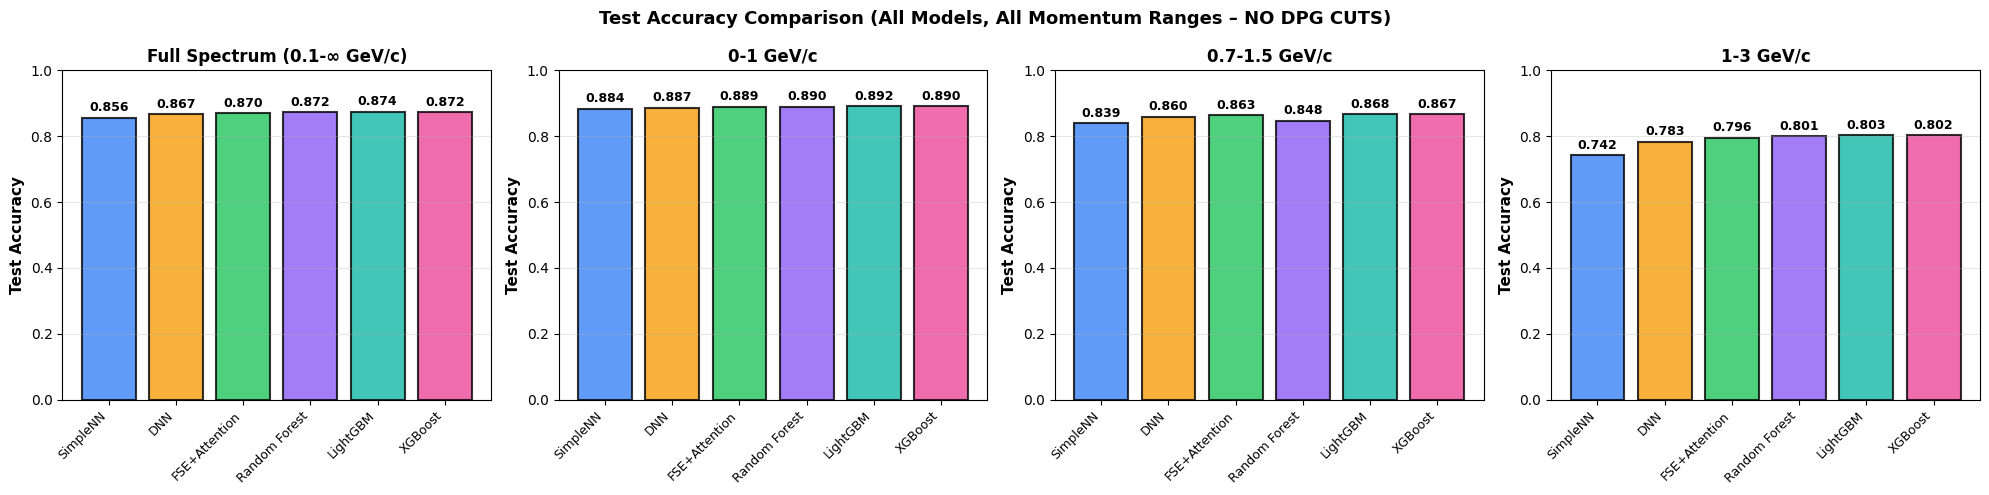

✓ Accuracy comparison plots generated (NO DPG cuts)

TEST ACCURACY COMPARISON (All Models, All Momentum Ranges – WITH DPG CUTS)



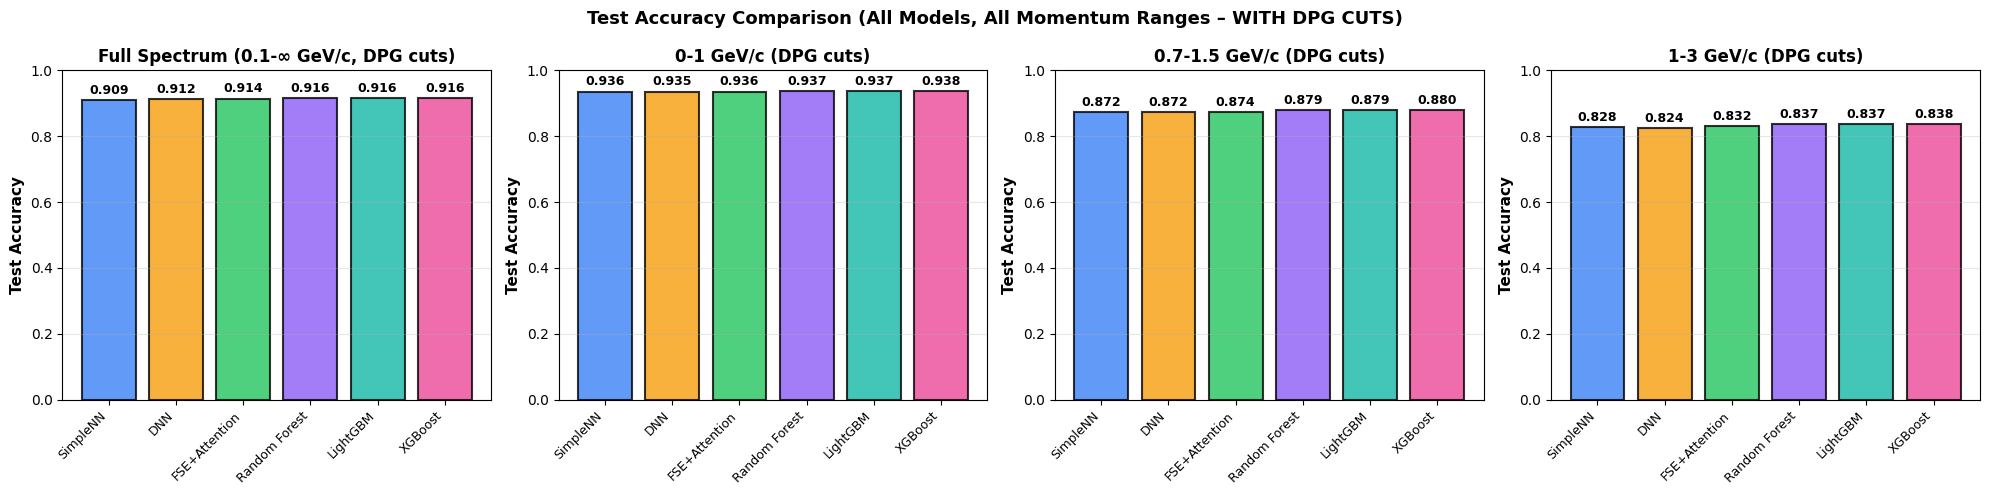

✓ Accuracy comparison plots generated (WITH DPG cuts)

BEST MODEL CONFUSION MATRICES – NO CUTS vs WITH DPG CUTS


Full Spectrum (0.1-∞ GeV/c) [NO DPG CUTS]
──────────────────────────────────────────────────────────────────────
  SimpleNN            : 0.8563
  DNN                 : 0.8669
  FSE+Attention       : 0.8703
  Random Forest       : 0.8722
  LightGBM            : 0.8744
  XGBoost             : 0.8724

✓ Best Model: LightGBM (0.8744)


0-1 GeV/c [NO DPG CUTS]
──────────────────────────────────────────────────────────────────────
  SimpleNN            : 0.8840
  DNN                 : 0.8866
  FSE+Attention       : 0.8893
  Random Forest       : 0.8900
  LightGBM            : 0.8922
  XGBoost             : 0.8903

✓ Best Model: LightGBM (0.8922)


0.7-1.5 GeV/c [NO DPG CUTS]
──────────────────────────────────────────────────────────────────────
  SimpleNN            : 0.8393
  DNN                 : 0.8595
  FSE+Attention       : 0.8633
  Random Forest       : 0.8476
  LightGBM   

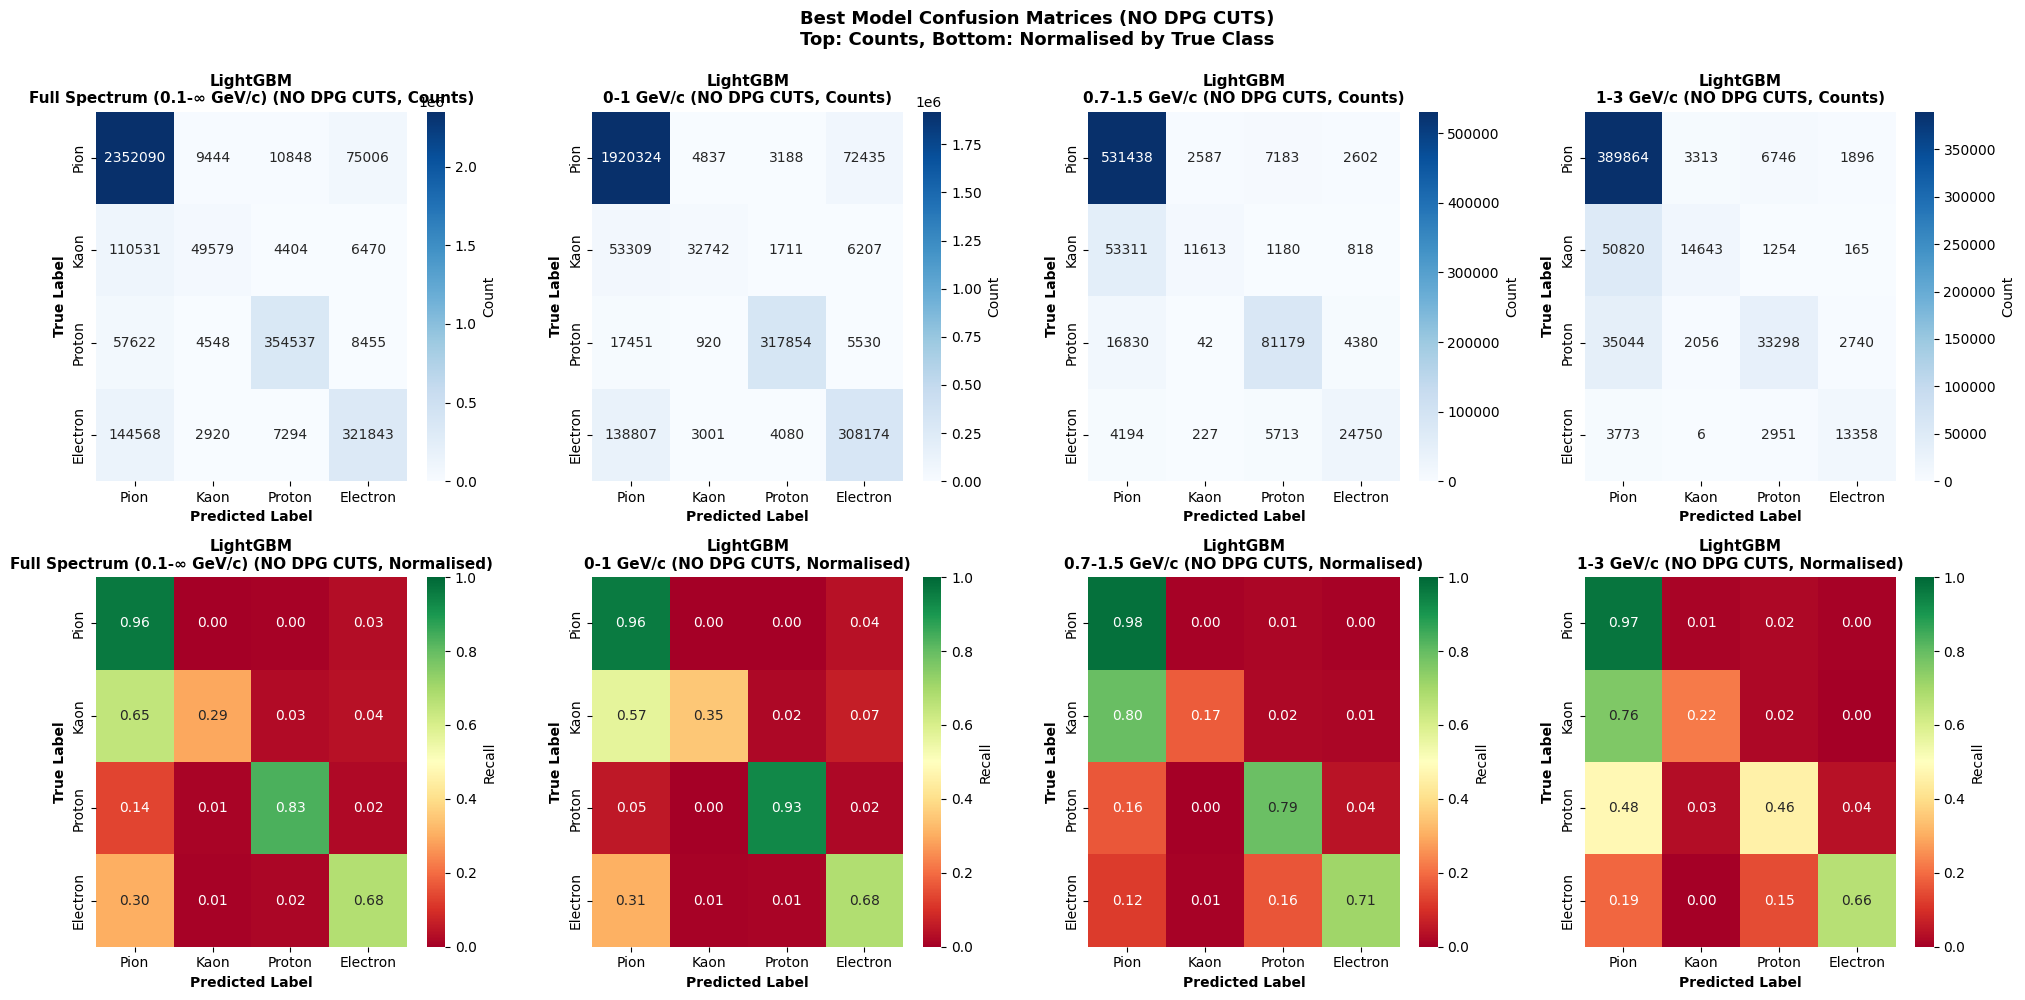


Full Spectrum (0.1-∞ GeV/c, DPG cuts) [WITH DPG CUTS]
──────────────────────────────────────────────────────────────────────
  SimpleNN            : 0.9094
  DNN                 : 0.9122
  FSE+Attention       : 0.9136
  Random Forest       : 0.9160
  LightGBM            : 0.9159
  XGBoost             : 0.9163

✓ Best Model: XGBoost (0.9163)


0-1 GeV/c (DPG cuts) [WITH DPG CUTS]
──────────────────────────────────────────────────────────────────────
  SimpleNN            : 0.9355
  DNN                 : 0.9351
  FSE+Attention       : 0.9357
  Random Forest       : 0.9372
  LightGBM            : 0.9372
  XGBoost             : 0.9375

✓ Best Model: XGBoost (0.9375)


0.7-1.5 GeV/c (DPG cuts) [WITH DPG CUTS]
──────────────────────────────────────────────────────────────────────
  SimpleNN            : 0.8723
  DNN                 : 0.8722
  FSE+Attention       : 0.8737
  Random Forest       : 0.8791
  LightGBM            : 0.8789
  XGBoost             : 0.8796

✓ Best Model: XGBoost (0.87

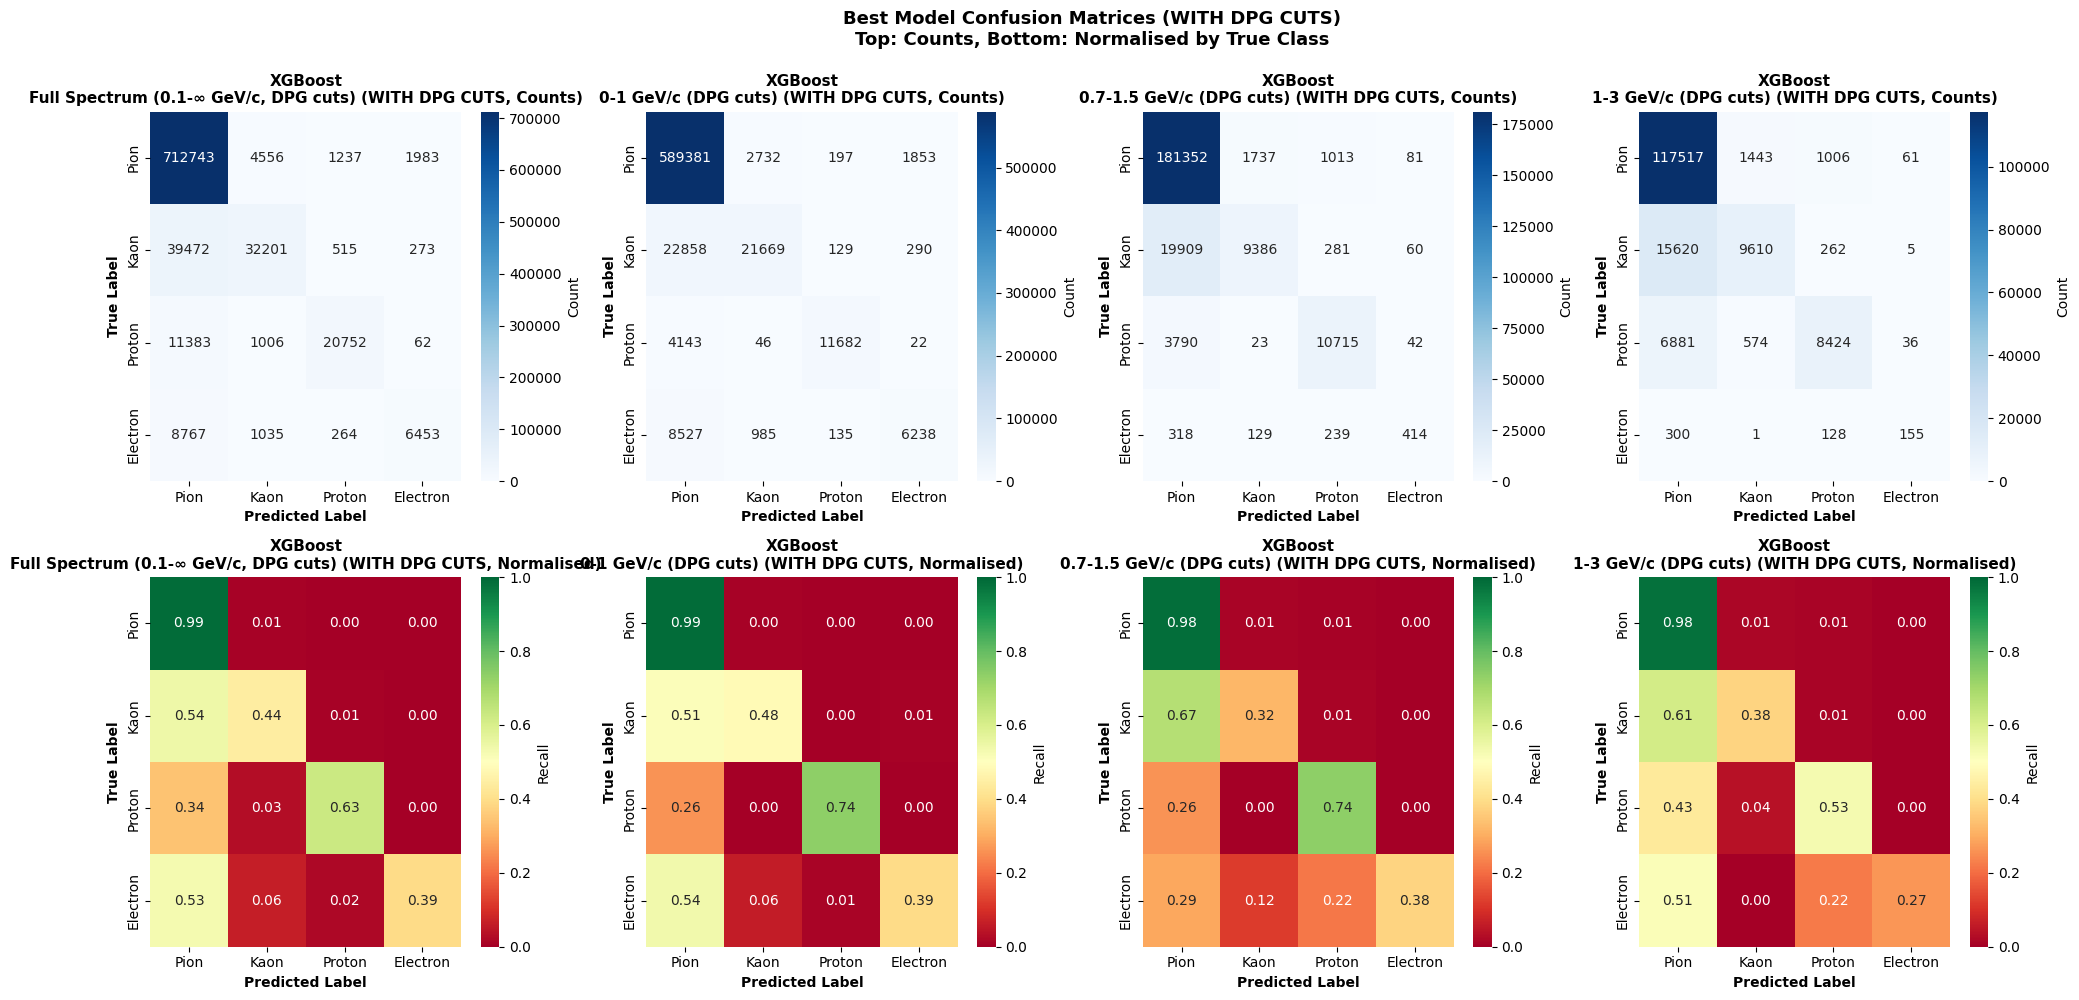


✓ Confusion matrices generated for best models (NO vs WITH DPG cuts)

PERFORMANCE RANKING – All Models, All Ranges

PERFORMANCE RANKING (NO DPG CUTS):

 Rank         Model              Momentum Range         Set  Test Acc  Train Time (s)
    1      LightGBM                   0-1 GeV/c NO DPG CUTS  0.892244             0.0
    2       XGBoost                   0-1 GeV/c NO DPG CUTS  0.890287             0.0
    3 Random Forest                   0-1 GeV/c NO DPG CUTS  0.890049             0.0
    4 FSE+Attention                   0-1 GeV/c NO DPG CUTS  0.889254             0.0
    5           DNN                   0-1 GeV/c NO DPG CUTS  0.886598             0.0
    6      SimpleNN                   0-1 GeV/c NO DPG CUTS  0.884023             0.0
    7      LightGBM Full Spectrum (0.1-∞ GeV/c) NO DPG CUTS  0.874406             0.0
    8       XGBoost Full Spectrum (0.1-∞ GeV/c) NO DPG CUTS  0.872411             0.0
    9 Random Forest Full Spectrum (0.1-∞ GeV/c) NO DPG CUTS  0.872179    

In [15]:
# ============================================================================
# SECTION 5B: COMPARISON & PERFORMANCE (WITH / WITHOUT DPG CUTS)
# ============================================================================

print(f"\n{'#'*80}")
print("SECTION 5: COMPARISON & PERFORMANCE (WITH / WITHOUT DPG CUTS)")
print(f"{'#'*80}\n")

# ---------------------------------------------------------------------------
# Helper: split momentum ranges into no-cuts vs DPG-cuts
# ---------------------------------------------------------------------------
momentum_by_key = {mr['key']: mr for mr in MOMENTUM_RANGES}

base_keys = [mr['key'] for mr in MOMENTUM_RANGES
             if not mr.get('apply_dpg_cuts', False)]
dpg_keys  = [mr['key'] for mr in MOMENTUM_RANGES
             if mr.get('apply_dpg_cuts', False)]

print("Non-DPG momentum ranges:", base_keys)
print("DPG momentum ranges    :", dpg_keys)

# Optional: display names for models (override safely if already defined)
model_display_names = {
    'JAX_SimpleNN':      'SimpleNN',
    'JAX_DNN':           'DNN',
    'JAX_FSE_Attention': 'FSE+Attention',
    'RandomForest':      'Random Forest',
    'LightGBM':          'LightGBM',
    'XGBoost':           'XGBoost',
}

# ============================================================================
# PART 1: TEST ACCURACY COMPARISON – NO DPG CUTS
# ============================================================================

print(f"\n{'='*80}")
print("TEST ACCURACY COMPARISON (All Models, All Momentum Ranges – NO DPG CUTS)")
print(f"{'='*80}\n")

if base_keys:
    fig, axes = plt.subplots(
        1, len(base_keys),
        figsize=(5 * len(base_keys), 5),
        squeeze=False
    )

    for idx, mr_key in enumerate(base_keys):
        momentum_range = momentum_by_key[mr_key]
        ax = axes[0, idx]

        x_pos = np.arange(len(MODEL_TYPES))
        test_accs = []
        colors = []

        models_dict = all_results_by_model_and_range.get(mr_key, {}).get('models', {})

        for model_type in MODEL_TYPES:
            if model_type in models_dict:
                results = models_dict[model_type]
                test_accs.append(results['test_acc'])
                colors.append(model_colors.get(model_type, '#999999'))
            else:
                test_accs.append(0.0)
                colors.append('#CCCCCC')

        bars = ax.bar(x_pos, test_accs,
                      color=colors, alpha=0.8,
                      edgecolor='black', linewidth=1.5)

        # Add value labels
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width() / 2., height + 0.01,
                        f'{height:.3f}', ha='center', va='bottom',
                        fontsize=9, fontweight='bold')

        ax.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
        ax.set_title(momentum_range['name'], fontsize=12, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(
            [model_display_names.get(m, m) for m in MODEL_TYPES],
            rotation=45, ha='right', fontsize=9
        )
        ax.set_ylim([0, 1.0])
        ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Test Accuracy Comparison (All Models, All Momentum Ranges – NO DPG CUTS)',
                 fontsize=13, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

    print("✓ Accuracy comparison plots generated (NO DPG cuts)")
else:
    print("No non-DPG momentum ranges found; skipping Part 1.")

# ============================================================================
# PART 2: TEST ACCURACY COMPARISON – WITH DPG CUTS
# ============================================================================

print(f"\n{'='*80}")
print("TEST ACCURACY COMPARISON (All Models, All Momentum Ranges – WITH DPG CUTS)")
print(f"{'='*80}\n")

if dpg_keys:
    fig, axes = plt.subplots(
        1, len(dpg_keys),
        figsize=(5 * len(dpg_keys), 5),
        squeeze=False
    )

    for idx, mr_key in enumerate(dpg_keys):
        momentum_range = momentum_by_key[mr_key]
        ax = axes[0, idx]

        x_pos = np.arange(len(MODEL_TYPES))
        test_accs = []
        colors = []

        models_dict = all_results_by_model_and_range.get(mr_key, {}).get('models', {})

        for model_type in MODEL_TYPES:
            if model_type in models_dict:
                results = models_dict[model_type]
                test_accs.append(results['test_acc'])
                colors.append(model_colors.get(model_type, '#999999'))
            else:
                test_accs.append(0.0)
                colors.append('#CCCCCC')

        bars = ax.bar(x_pos, test_accs,
                      color=colors, alpha=0.8,
                      edgecolor='black', linewidth=1.5)

        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width() / 2., height + 0.01,
                        f'{height:.3f}', ha='center', va='bottom',
                        fontsize=9, fontweight='bold')

        ax.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
        ax.set_title(momentum_range['name'], fontsize=12, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(
            [model_display_names.get(m, m) for m in MODEL_TYPES],
            rotation=45, ha='right', fontsize=9
        )
        ax.set_ylim([0, 1.0])
        ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Test Accuracy Comparison (All Models, All Momentum Ranges – WITH DPG CUTS)',
                 fontsize=13, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

    print("✓ Accuracy comparison plots generated (WITH DPG cuts)")
else:
    print("No DPG momentum ranges found; skipping Part 2.")

# ============================================================================
# PART 3: BEST-MODEL CONFUSION MATRICES – NO CUTS vs DPG CUTS
# ============================================================================

print(f"\n{'='*80}")
print("BEST MODEL CONFUSION MATRICES – NO CUTS vs WITH DPG CUTS")
print(f"{'='*80}\n")

from sklearn.metrics import confusion_matrix

# Helper to plot best-model confusion matrices for a set of keys
def plot_best_confusions_for_keys(mr_keys, title_suffix):
    if not mr_keys:
        print(f"No momentum ranges for {title_suffix}; skipping.")
        return

    fig, axes = plt.subplots(
        2, len(mr_keys),
        figsize=(5 * len(mr_keys), 10),
        squeeze=False
    )

    for idx, mr_key in enumerate(mr_keys):
        momentum_range = momentum_by_key[mr_key]
        models_dict = all_results_by_model_and_range.get(mr_key, {}).get('models', {})

        if not models_dict:
            print(f"No models found for {momentum_range['name']} ({mr_key}); skipping.")
            continue

        print(f"\n{momentum_range['name']} [{title_suffix}]")
        print("─" * 70)

        # Select best model by test accuracy
        best_model = None
        best_acc = -1.0

        for model_type in MODEL_TYPES:
            if model_type in models_dict:
                acc = models_dict[model_type]['test_acc']
                print(f"  {model_display_names.get(model_type, model_type):20s}: {acc:.4f}")
                if acc > best_acc:
                    best_acc = acc
                    best_model = model_type

        if best_model is None:
            print("  No valid models for this range; skipping confusion matrices.")
            continue

        print(f"\n✓ Best Model: {model_display_names.get(best_model, best_model)} ({best_acc:.4f})\n")

        y_test = np.array(models_dict[best_model]['y_test'])
        y_pred = np.array(models_dict[best_model]['y_pred_test'])

        cm = confusion_matrix(y_test, y_pred)
        cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

        # Counts matrix
        ax_counts = axes[0, idx]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_counts,
                    xticklabels=PARTICLE_NAMES, yticklabels=PARTICLE_NAMES,
                    cbar_kws={'label': 'Count'}, vmin=0)
        ax_counts.set_ylabel('True Label', fontsize=10, fontweight='bold')
        ax_counts.set_xlabel('Predicted Label', fontsize=10, fontweight='bold')
        ax_counts.set_title(
            f"{model_display_names.get(best_model, best_model)}\n"
            f"{momentum_range['name']} ({title_suffix}, Counts)",
            fontsize=11, fontweight='bold'
        )

        # Normalised matrix
        ax_norm = axes[1, idx]
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax_norm,
                    xticklabels=PARTICLE_NAMES, yticklabels=PARTICLE_NAMES,
                    cbar_kws={'label': 'Recall'}, vmin=0, vmax=1)
        ax_norm.set_ylabel('True Label', fontsize=10, fontweight='bold')
        ax_norm.set_xlabel('Predicted Label', fontsize=10, fontweight='bold')
        ax_norm.set_title(
            f"{model_display_names.get(best_model, best_model)}\n"
            f"{momentum_range['name']} ({title_suffix}, Normalised)",
            fontsize=11, fontweight='bold'
        )

    plt.suptitle(
        f"Best Model Confusion Matrices ({title_suffix})\n"
        f"Top: Counts, Bottom: Normalised by True Class",
        fontsize=13, fontweight='bold', y=0.995
    )
    plt.tight_layout()
    plt.show()

# Confusions without cuts
plot_best_confusions_for_keys(base_keys, "NO DPG CUTS")

# Confusions with DPG cuts
plot_best_confusions_for_keys(dpg_keys, "WITH DPG CUTS")

print("\n" + "="*80)
print("✓ Confusion matrices generated for best models (NO vs WITH DPG cuts)")
print("="*80)

# ============================================================================
# PART 4: PERFORMANCE RANKING – NO CUTS vs DPG CUTS vs COMBINED
# ============================================================================

print(f"\n{'='*80}")
print("PERFORMANCE RANKING – All Models, All Ranges")
print(f"{'='*80}\n")

def build_ranking_for_keys(mr_keys, label):
    ranking_data = []

    for mr_key in mr_keys:
        momentum_range = momentum_by_key[mr_key]
        models_dict = all_results_by_model_and_range.get(mr_key, {}).get('models', {})

        for model_type in MODEL_TYPES:
            if model_type in models_dict:
                results = models_dict[model_type]
                ranking_data.append({
                    'Model': model_display_names.get(model_type, model_type),
                    'Momentum Range': momentum_range['name'],
                    'Set': label,
                    'Test Acc': results['test_acc'],
                    'Train Time (s)': results.get('training_time', 0.0),
                })

    if not ranking_data:
        return None

    df = pd.DataFrame(ranking_data).sort_values('Test Acc', ascending=False).reset_index(drop=True)
    df.insert(0, 'Rank', np.arange(1, len(df) + 1))
    return df

# No DPG cuts
ranking_no_dpg = build_ranking_for_keys(base_keys, 'NO DPG CUTS')
if ranking_no_dpg is not None:
    print("PERFORMANCE RANKING (NO DPG CUTS):\n")
    print(ranking_no_dpg.to_string(index=False))
    print()
else:
    print("No data for NO DPG CUTS ranking.\n")

# With DPG cuts
ranking_dpg = build_ranking_for_keys(dpg_keys, 'WITH DPG CUTS')
if ranking_dpg is not None:
    print("PERFORMANCE RANKING (WITH DPG CUTS):\n")
    print(ranking_dpg.to_string(index=False))
    print()
else:
    print("No data for WITH DPG CUTS ranking.\n")

# Combined
if ranking_no_dpg is not None or ranking_dpg is not None:
    combined_parts = []
    if ranking_no_dpg is not None:
        combined_parts.append(ranking_no_dpg.drop(columns=['Rank']))
    if ranking_dpg is not None:
        combined_parts.append(ranking_dpg.drop(columns=['Rank']))

    ranking_all = pd.concat(combined_parts, ignore_index=True)
    ranking_all = ranking_all.sort_values('Test Acc', ascending=False).reset_index(drop=True)
    ranking_all.insert(0, 'Rank', np.arange(1, len(ranking_all) + 1))

    print("PERFORMANCE RANKING (NO DPG CUTS + WITH DPG CUTS COMBINED):\n")
    print(ranking_all.to_string(index=False))
    print()
else:
    print("No data for combined ranking.\n")

print(f"{'='*80}")
print("✓ SECTION 5B COMPLETE: Comparisons and rankings with/without DPG cuts")
print(f"{'='*80}\n")


### Section 5C: ROC / AUC Analysis


################################################################################
SECTION 6: ROC / AUC ANALYSIS (WITH & WITHOUT DPG CUTS)
################################################################################

Non-DPG momentum ranges: ['full', '0.1-1', '0.7-1.5', '1-3']
DPG momentum ranges    : ['full_DPG', '0.1-1_DPG', '0.7-1.5_DPG', '1-3_DPG']

ROC CURVES: MACRO AUC (All Models, All Momentum Ranges – NO DPG CUTS)



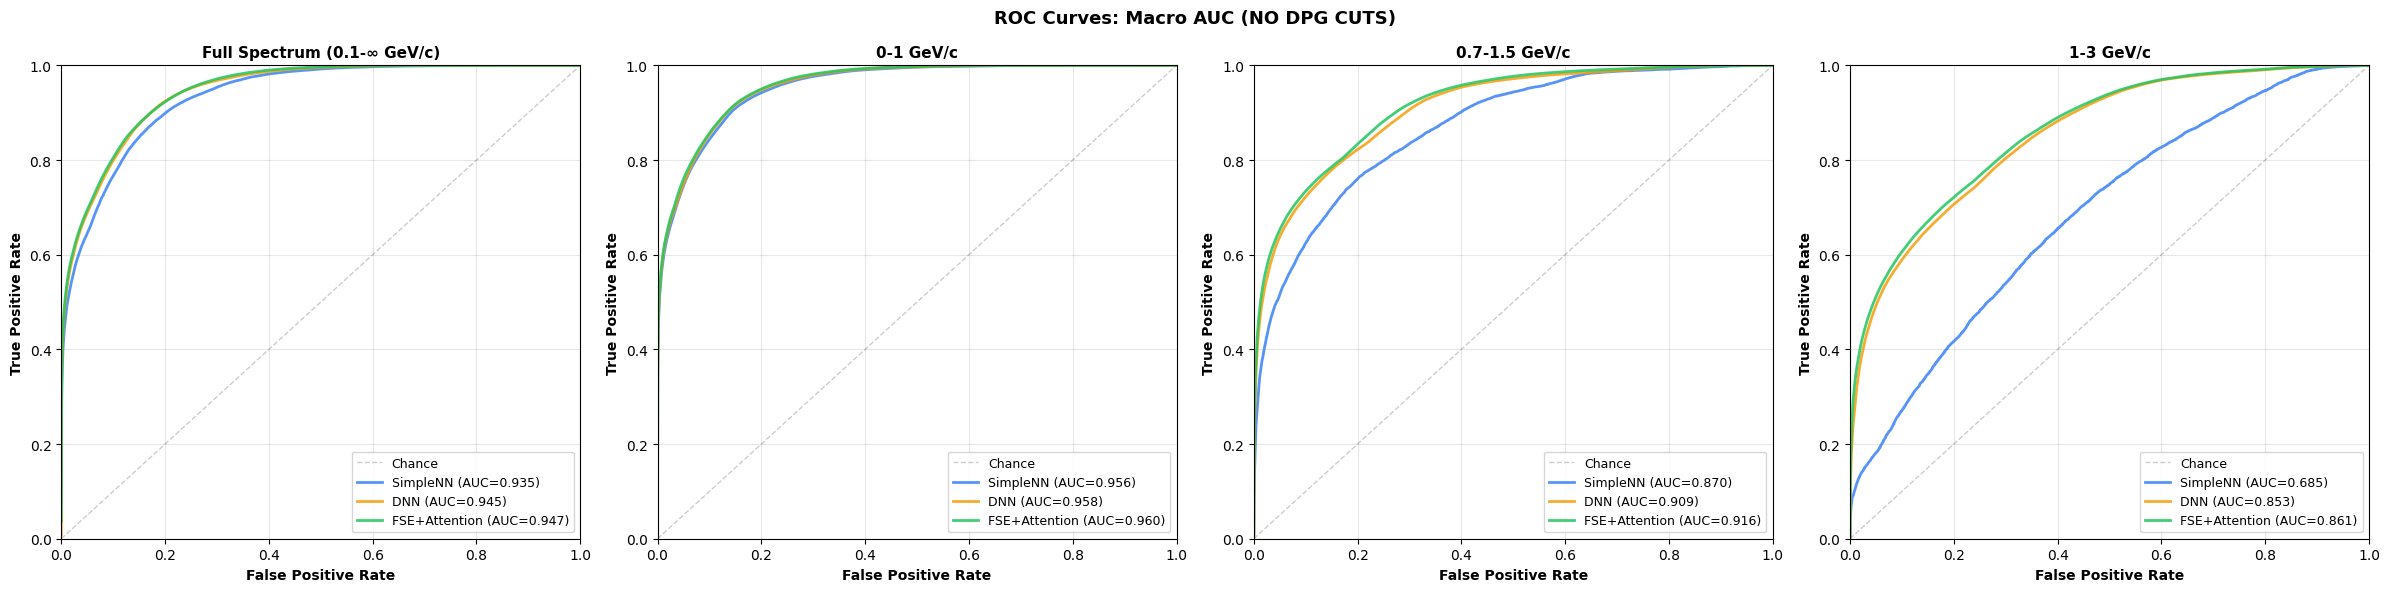


ROC CURVES: MACRO AUC (All Models, All Momentum Ranges – WITH DPG CUTS)



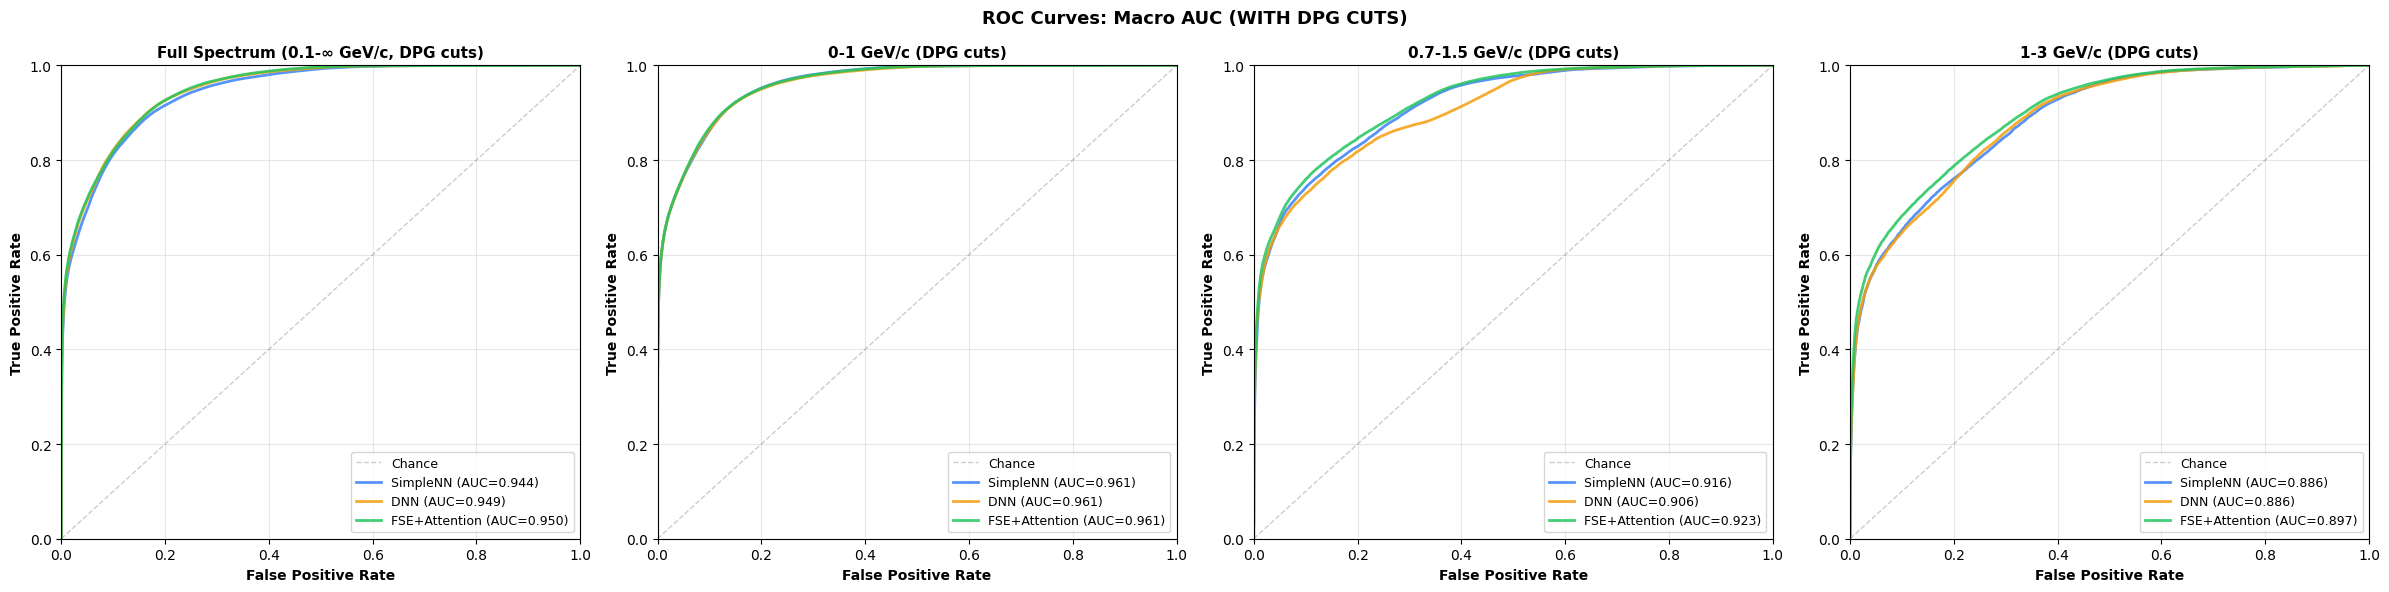


ONE-VS-REST ROC CURVES (All Models, All Ranges – NO DPG CUTS)



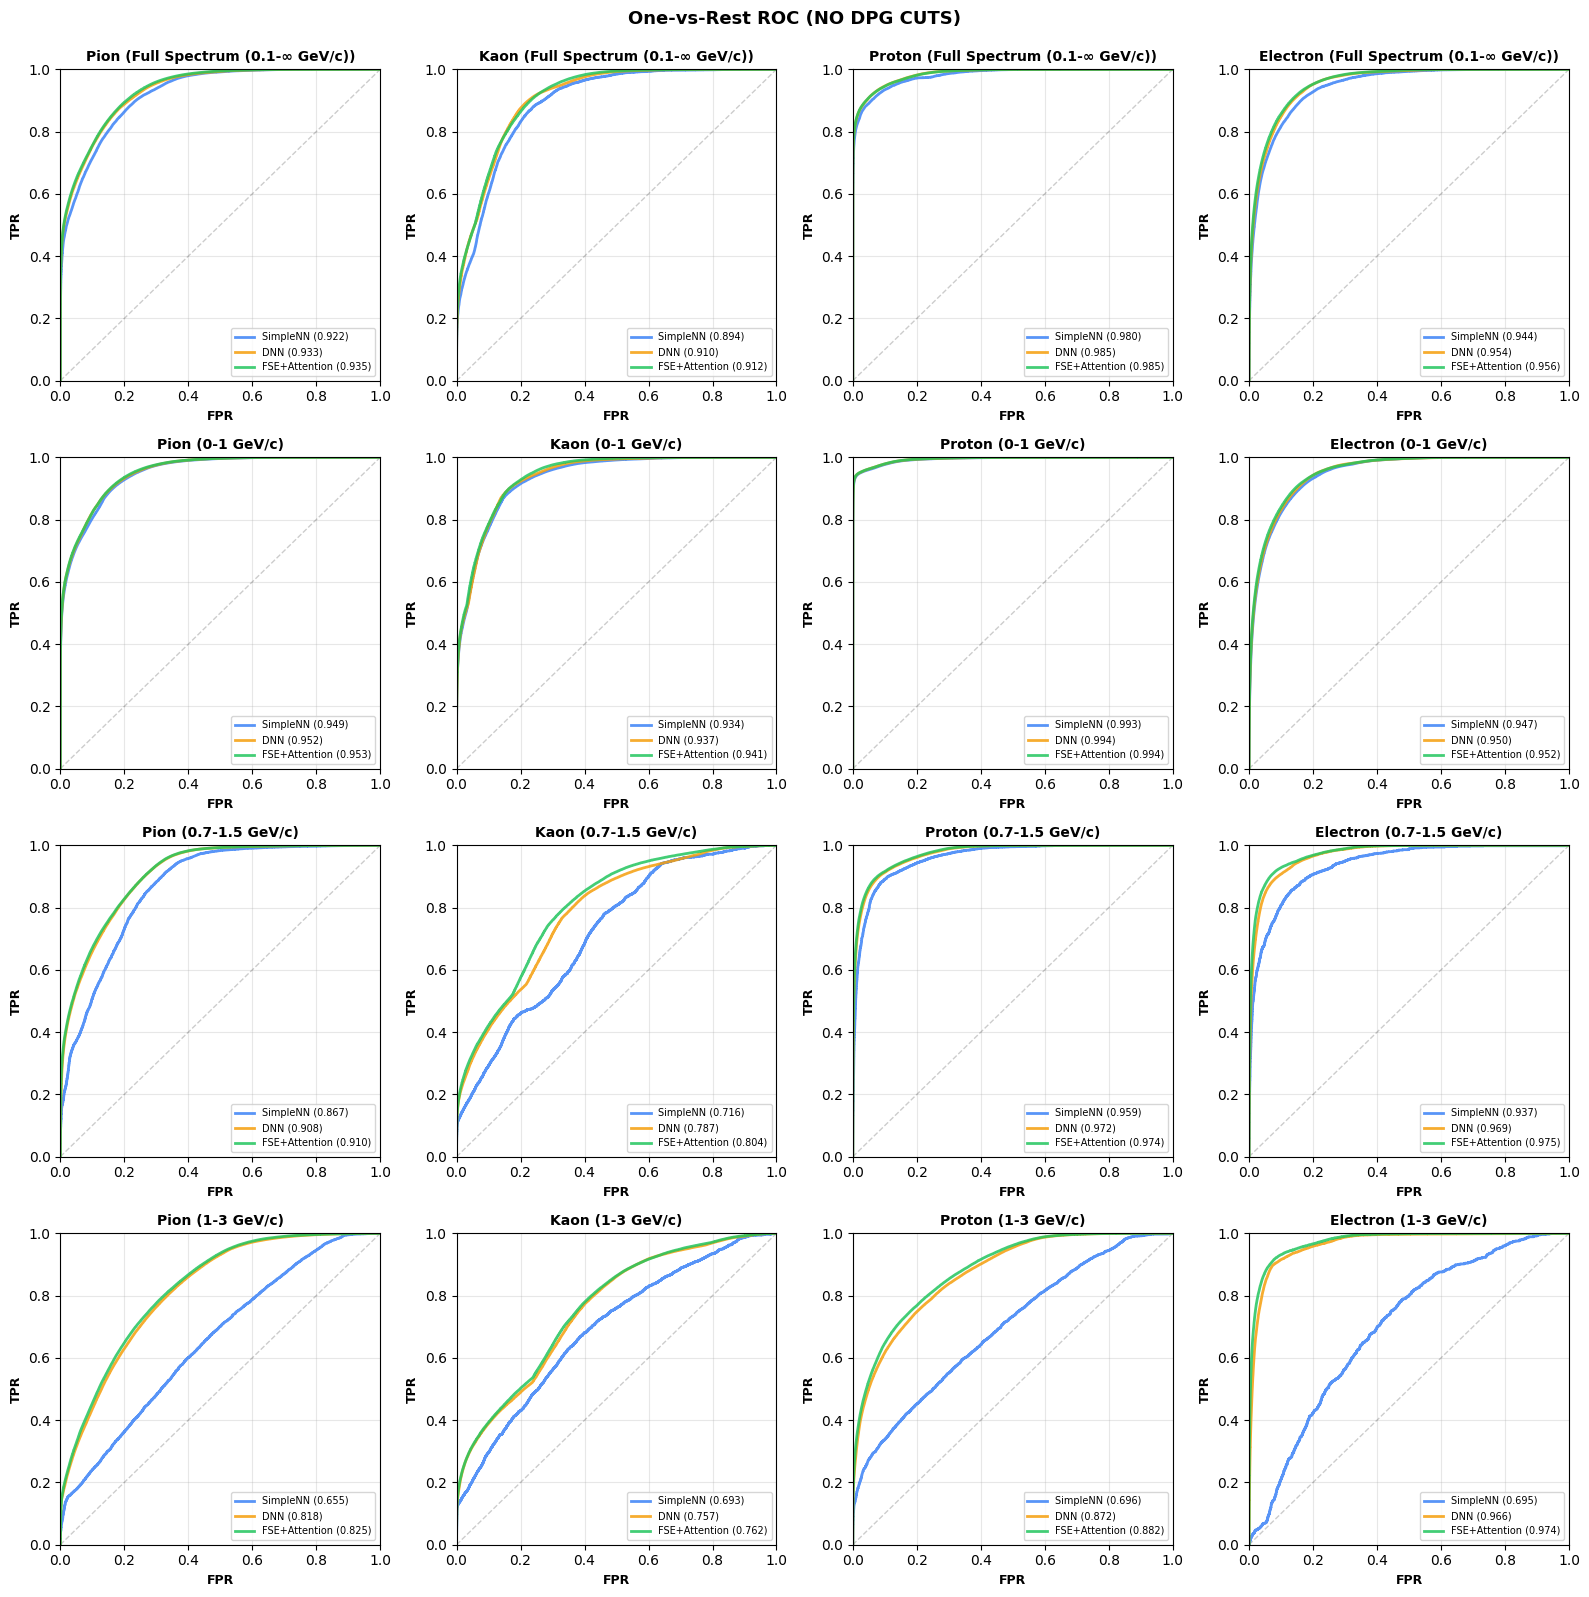


ONE-VS-REST ROC CURVES (All Models, All Ranges – WITH DPG CUTS)



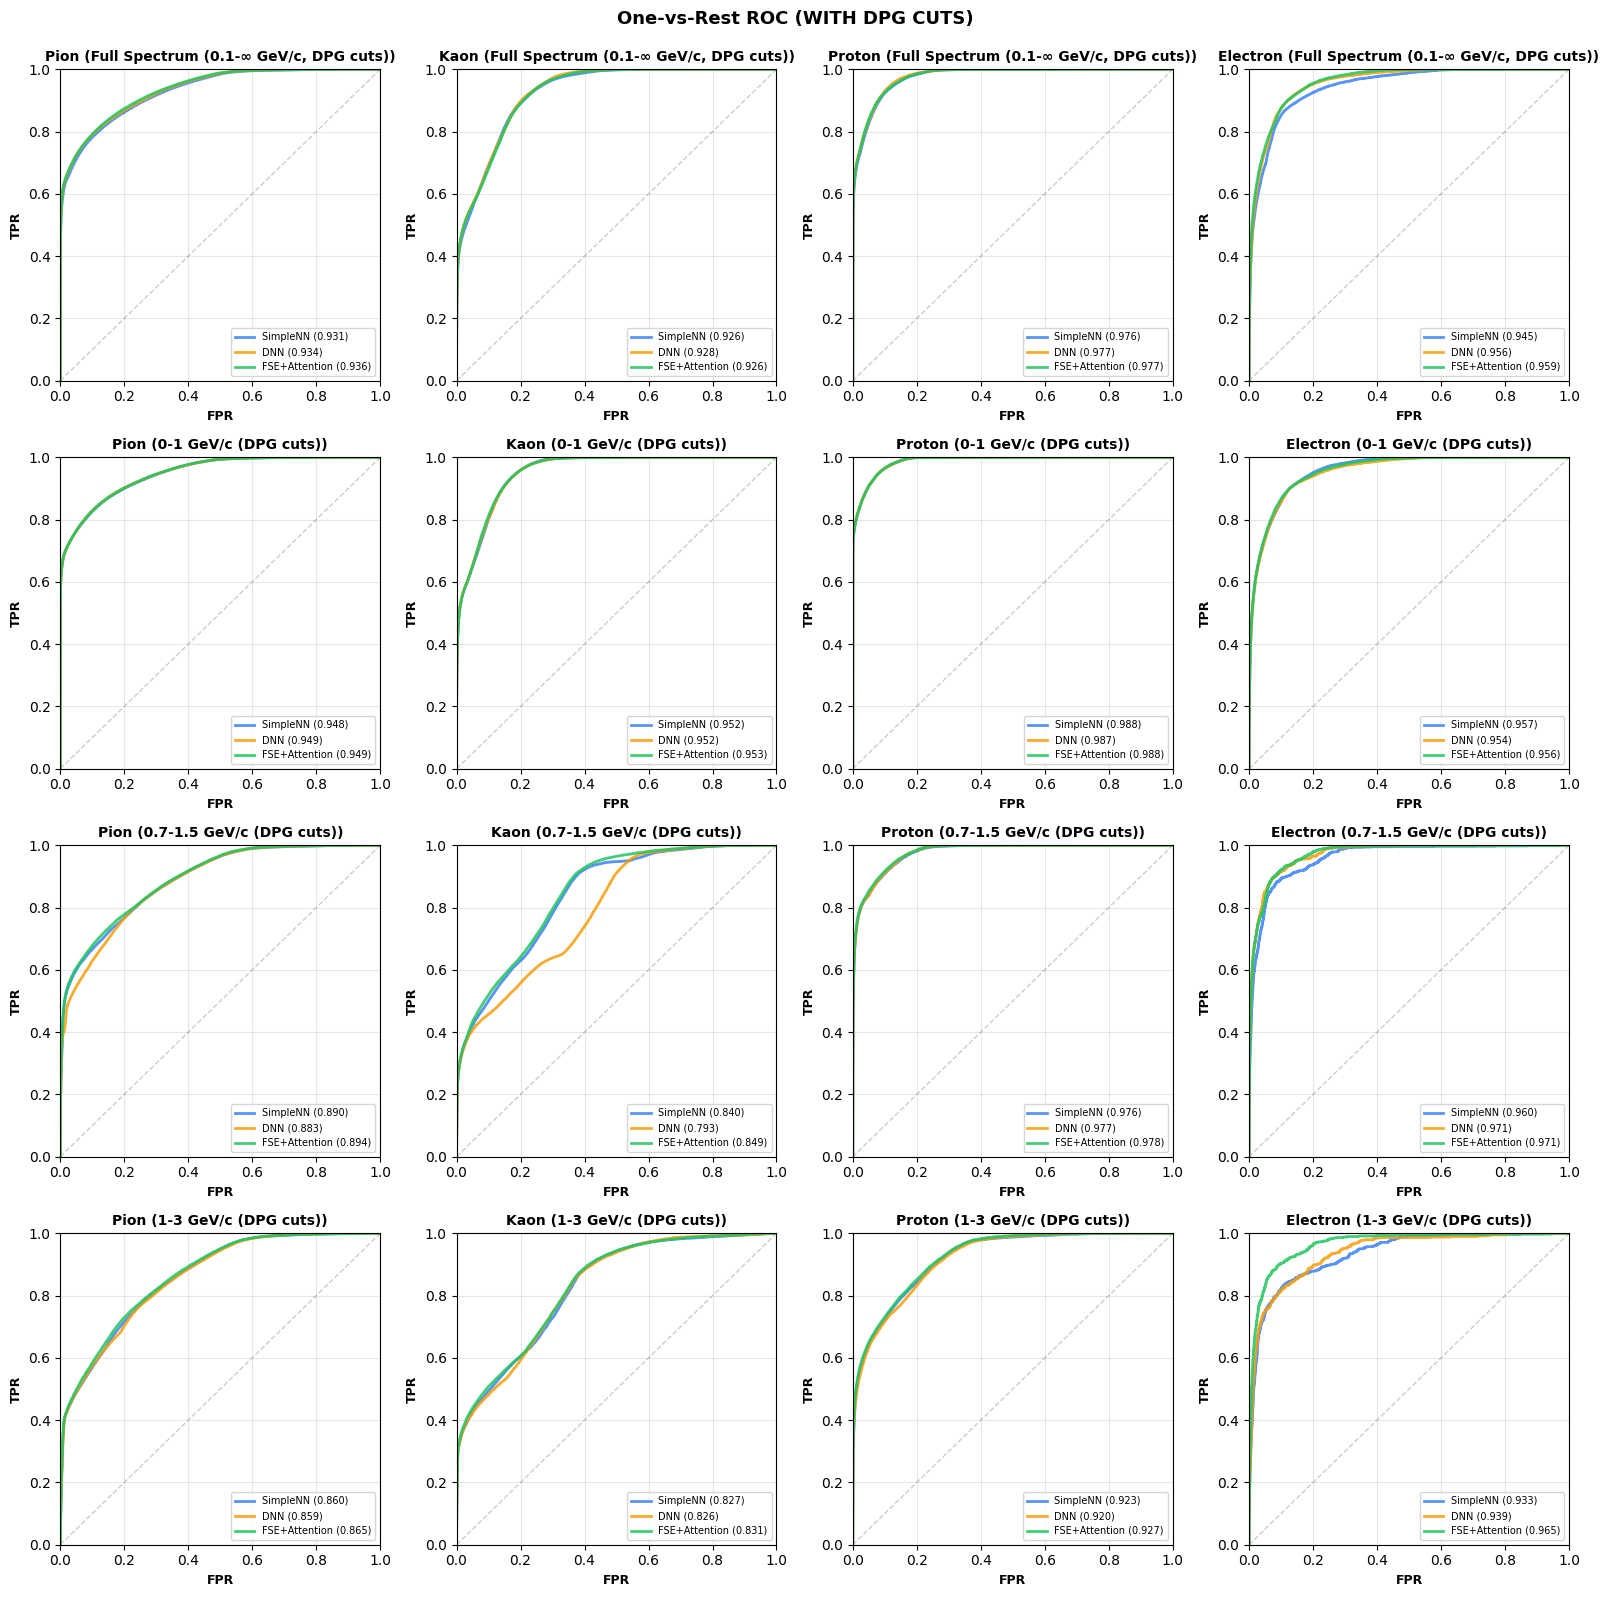


MACRO AUC SUMMARY TABLES & RANKINGS

MACRO AUC SUMMARY TABLE (NO DPG CUTS):

             Momentum Range         Model  Macro AUC
Full Spectrum (0.1-∞ GeV/c)      SimpleNN   0.935026
Full Spectrum (0.1-∞ GeV/c)           DNN   0.945348
Full Spectrum (0.1-∞ GeV/c) FSE+Attention   0.947104
                  0-1 GeV/c      SimpleNN   0.955989
                  0-1 GeV/c           DNN   0.958349
                  0-1 GeV/c FSE+Attention   0.959889
              0.7-1.5 GeV/c      SimpleNN   0.869835
              0.7-1.5 GeV/c           DNN   0.909167
              0.7-1.5 GeV/c FSE+Attention   0.915782
                  1-3 GeV/c      SimpleNN   0.684784
                  1-3 GeV/c           DNN   0.853183
                  1-3 GeV/c FSE+Attention   0.860862

MACRO AUC SUMMARY TABLE (WITH DPG CUTS):

                       Momentum Range         Model  Macro AUC
Full Spectrum (0.1-∞ GeV/c, DPG cuts)      SimpleNN   0.944204
Full Spectrum (0.1-∞ GeV/c, DPG cuts)           DNN   0.948832
F

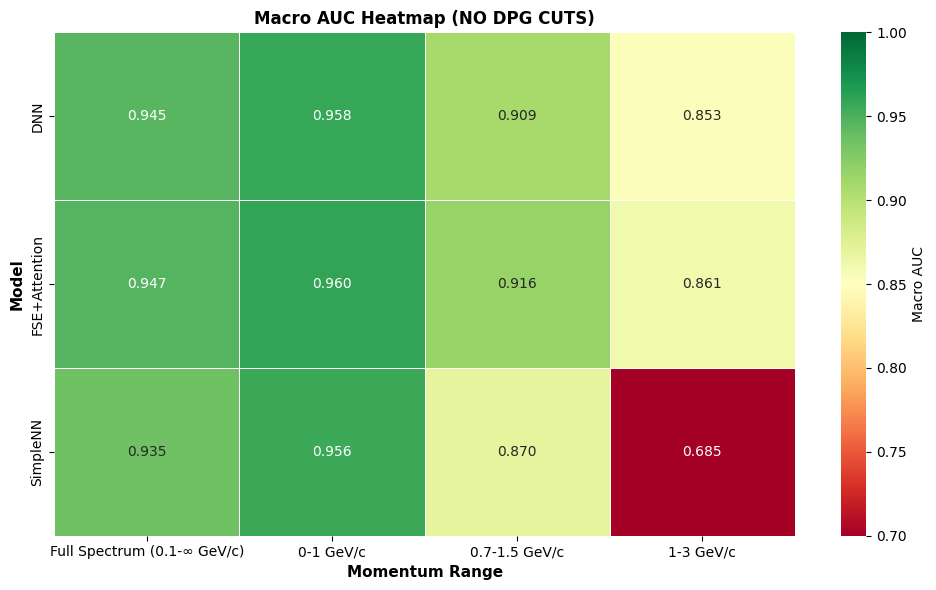


Heatmap – WITH DPG CUTS:


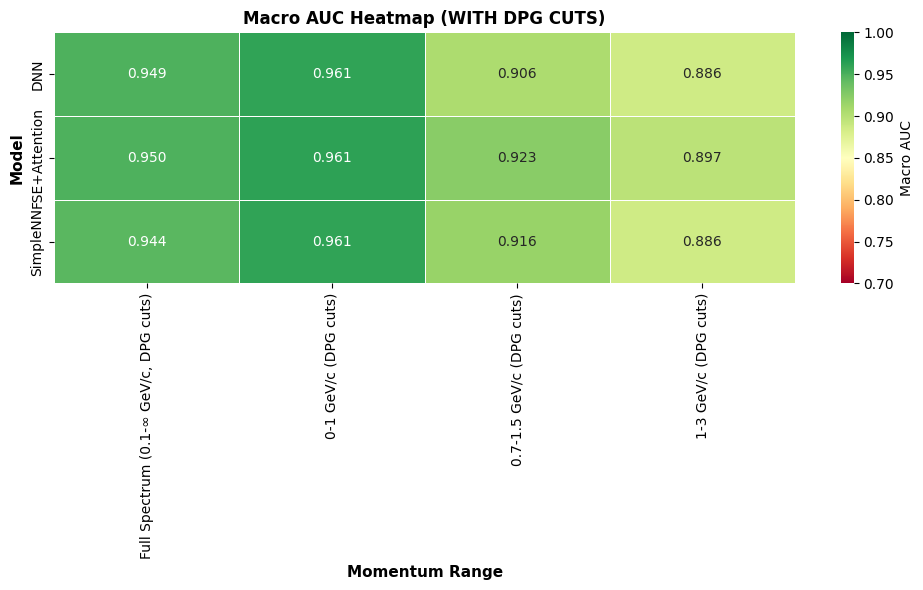


MACRO AUC SUMMARY STATISTICS BY MODEL

MACRO AUC SUMMARY STATISTICS BY MODEL (NO DPG CUTS):

        Model  Avg Macro AUC  Min Macro AUC  Max Macro AUC  Std Dev
FSE+Attention       0.920909       0.860862       0.959889 0.038202
          DNN       0.916512       0.853183       0.958349 0.040762
     SimpleNN       0.861408       0.684784       0.955989 0.106809

MACRO AUC SUMMARY STATISTICS BY MODEL (WITH DPG CUTS):

        Model  Avg Macro AUC  Min Macro AUC  Max Macro AUC  Std Dev
FSE+Attention       0.932706       0.896967       0.961458 0.024916
     SimpleNN       0.926922       0.885739       0.961269 0.028651
          DNN       0.925270       0.885724       0.960541 0.030558

✓ SECTION 5C COMPLETE: ROC / AUC Analysis with & without DPG cuts



In [16]:
# ============================================================================
# SECTION 5C: ROC / AUC ANALYSIS WITH & WITHOUT DPG CUTS
# ============================================================================

print(f"\n{'#'*80}")
print("SECTION 6: ROC / AUC ANALYSIS (WITH & WITHOUT DPG CUTS)")
print(f"{'#'*80}\n")

# ---------------------------------------------------------------------------
# Helper: safe macro AUC (reusable)
# ---------------------------------------------------------------------------
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def calculate_macro_auc_safe(y_test, y_test_probs):
    """
    Safely calculate macro AUC from test probabilities.
    Returns NaN if calculation fails.
    """
    try:
        y_test = np.array(y_test)
        y_test_probs = np.array(y_test_probs)
        y_test_bin = label_binarize(y_test, classes=np.arange(NUM_CLASSES))
        auc_scores = []
        for i in range(NUM_CLASSES):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_probs[:, i])
            auc_score = auc(fpr, tpr)
            auc_scores.append(auc_score)
        return float(np.mean(auc_scores))
    except Exception:
        return np.nan

# ---------------------------------------------------------------------------
# Split momentum ranges: no DPG vs DPG
# ---------------------------------------------------------------------------
momentum_by_key = {mr['key']: mr for mr in MOMENTUM_RANGES}
base_keys = [mr['key'] for mr in MOMENTUM_RANGES
             if not mr.get('apply_dpg_cuts', False)]
dpg_keys  = [mr['key'] for mr in MOMENTUM_RANGES
             if mr.get('apply_dpg_cuts', False)]

print("Non-DPG momentum ranges:", base_keys)
print("DPG momentum ranges    :", dpg_keys)

# Display names for plots
model_display_names = {
    'JAX_SimpleNN':      'SimpleNN',
    'JAX_DNN':           'DNN',
    'JAX_FSE_Attention': 'FSE+Attention',
    'RandomForest':      'Random Forest',
    'LightGBM':          'LightGBM',
    'XGBoost':           'XGBoost',
}

# ============================================================================
# PART 1: ROC CURVES – MACRO AUC (NO DPG vs WITH DPG)
# ============================================================================

print(f"\n{'='*80}")
print("ROC CURVES: MACRO AUC (All Models, All Momentum Ranges – NO DPG CUTS)")
print(f"{'='*80}\n")

macro_auc_no_dpg = {}   # {mr_key: {model_type: macro_auc}}

if base_keys:
    fig, axes = plt.subplots(
        1, len(base_keys),
        figsize=(6 * len(base_keys), 6),
        squeeze=False
    )

    for idx, mr_key in enumerate(base_keys):
        mr = momentum_by_key[mr_key]
        ax = axes[0, idx]
        models_dict = all_results_by_model_and_range.get(mr_key, {}).get('models', {})
        macro_auc_no_dpg[mr_key] = {}

        if not models_dict:
            ax.set_title(f"{mr['name']} (no models)")
            ax.axis('off')
            continue

        # Chance line
        ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.2, label='Chance')

        for model_type in MODEL_TYPES:
            if model_type not in models_dict:
                continue

            results = models_dict[model_type]
            try:
                y_test = np.array(results['y_test'])
                y_probs = np.array(results['test_probs'])
                y_bin = label_binarize(y_test, classes=np.arange(NUM_CLASSES))

                # Per-class ROC
                fpr_all, tpr_all, auc_scores = [], [], []
                for i in range(NUM_CLASSES):
                    fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
                    auc_i = auc(fpr, tpr)
                    fpr_all.append(fpr)
                    tpr_all.append(tpr)
                    auc_scores.append(auc_i)

                macro_auc = float(np.mean(auc_scores))
                macro_auc_no_dpg[mr_key][model_type] = macro_auc

                # Interpolate to common grid for smooth macro curve
                all_fpr = np.unique(np.concatenate(fpr_all))
                mean_tpr = np.zeros_like(all_fpr)
                for i in range(NUM_CLASSES):
                    mean_tpr += np.interp(all_fpr, fpr_all[i], tpr_all[i])
                mean_tpr /= NUM_CLASSES

                ax.plot(all_fpr, mean_tpr,
                        label=f"{model_display_names.get(model_type, model_type)} (AUC={macro_auc:.3f})",
                        color=model_colors.get(model_type, '#999999'),
                        lw=2.0, alpha=0.85)
            except Exception as e:
                print(f"Warning: ROC failed for {model_type} / {mr_key}: {str(e)[:80]}")

        ax.set_xlabel('False Positive Rate', fontsize=10, fontweight='bold')
        ax.set_ylabel('True Positive Rate', fontsize=10, fontweight='bold')
        ax.set_title(mr['name'], fontsize=11, fontweight='bold')
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(alpha=0.3)

    plt.suptitle('ROC Curves: Macro AUC (NO DPG CUTS)',
                 fontsize=13, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
else:
    print("No non-DPG momentum ranges; skipping ROC (NO DPG CUTS).")

print(f"\n{'='*80}")
print("ROC CURVES: MACRO AUC (All Models, All Momentum Ranges – WITH DPG CUTS)")
print(f"{'='*80}\n")

macro_auc_dpg = {}      # {mr_key: {model_type: macro_auc}}

if dpg_keys:
    fig, axes = plt.subplots(
        1, len(dpg_keys),
        figsize=(6 * len(dpg_keys), 6),
        squeeze=False
    )

    for idx, mr_key in enumerate(dpg_keys):
        mr = momentum_by_key[mr_key]
        ax = axes[0, idx]
        models_dict = all_results_by_model_and_range.get(mr_key, {}).get('models', {})
        macro_auc_dpg[mr_key] = {}

        if not models_dict:
            ax.set_title(f"{mr['name']} (no models)")
            ax.axis('off')
            continue

        ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.2, label='Chance')

        for model_type in MODEL_TYPES:
            if model_type not in models_dict:
                continue

            results = models_dict[model_type]
            try:
                y_test = np.array(results['y_test'])
                y_probs = np.array(results['test_probs'])
                y_bin = label_binarize(y_test, classes=np.arange(NUM_CLASSES))

                fpr_all, tpr_all, auc_scores = [], [], []
                for i in range(NUM_CLASSES):
                    fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
                    auc_i = auc(fpr, tpr)
                    fpr_all.append(fpr)
                    tpr_all.append(tpr)
                    auc_scores.append(auc_i)

                macro_auc = float(np.mean(auc_scores))
                macro_auc_dpg[mr_key][model_type] = macro_auc

                all_fpr = np.unique(np.concatenate(fpr_all))
                mean_tpr = np.zeros_like(all_fpr)
                for i in range(NUM_CLASSES):
                    mean_tpr += np.interp(all_fpr, fpr_all[i], tpr_all[i])
                mean_tpr /= NUM_CLASSES

                ax.plot(all_fpr, mean_tpr,
                        label=f"{model_display_names.get(model_type, model_type)} (AUC={macro_auc:.3f})",
                        color=model_colors.get(model_type, '#999999'),
                        lw=2.0, alpha=0.85)
            except Exception as e:
                print(f"Warning: ROC failed for {model_type} / {mr_key}: {str(e)[:80]}")

        ax.set_xlabel('False Positive Rate', fontsize=10, fontweight='bold')
        ax.set_ylabel('True Positive Rate', fontsize=10, fontweight='bold')
        ax.set_title(mr['name'], fontsize=11, fontweight='bold')
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(alpha=0.3)

    plt.suptitle('ROC Curves: Macro AUC (WITH DPG CUTS)',
                 fontsize=13, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
else:
    print("No DPG momentum ranges; skipping ROC (WITH DPG CUTS).")

# ============================================================================
# PART 2: ONE-vs-REST ROC CURVES (NO DPG vs WITH DPG)
# ============================================================================

print(f"\n{'='*80}")
print("ONE-VS-REST ROC CURVES (All Models, All Ranges – NO DPG CUTS)")
print(f"{'='*80}\n")

if base_keys:
    fig, axes = plt.subplots(
        len(base_keys), len(PARTICLE_NAMES),
        figsize=(4 * len(PARTICLE_NAMES), 4 * len(base_keys)),
        squeeze=False
    )

    for r_idx, mr_key in enumerate(base_keys):
        mr = momentum_by_key[mr_key]
        models_dict = all_results_by_model_and_range.get(mr_key, {}).get('models', {})

        for p_idx, particle_name in enumerate(PARTICLE_NAMES):
            ax = axes[r_idx, p_idx]
            ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.2)

            for model_type in MODEL_TYPES:
                if model_type not in models_dict:
                    continue
                try:
                    results = models_dict[model_type]
                    y_test = np.array(results['y_test'])
                    y_probs = np.array(results['test_probs'])

                    y_bin = (y_test == p_idx).astype(int)
                    fpr, tpr, _ = roc_curve(y_bin, y_probs[:, p_idx])
                    roc_auc_val = auc(fpr, tpr)

                    ax.plot(fpr, tpr,
                            label=f"{model_display_names.get(model_type, model_type)} ({roc_auc_val:.3f})",
                            color=model_colors.get(model_type, '#999999'),
                            lw=2.0, alpha=0.85)
                except Exception:
                    pass

            ax.set_xlabel('FPR', fontsize=9, fontweight='bold')
            ax.set_ylabel('TPR', fontsize=9, fontweight='bold')
            ax.set_title(f"{particle_name} ({mr['name']})", fontsize=10, fontweight='bold')
            ax.set_xlim([0, 1])
            ax.set_ylim([0, 1])
            ax.legend(loc='lower right', fontsize=7)
            ax.grid(alpha=0.3)

    plt.suptitle('One-vs-Rest ROC (NO DPG CUTS)',
                 fontsize=13, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
else:
    print("No non-DPG ranges; skipping one-vs-rest (NO DPG CUTS).")

print(f"\n{'='*80}")
print("ONE-VS-REST ROC CURVES (All Models, All Ranges – WITH DPG CUTS)")
print(f"{'='*80}\n")

if dpg_keys:
    fig, axes = plt.subplots(
        len(dpg_keys), len(PARTICLE_NAMES),
        figsize=(4 * len(PARTICLE_NAMES), 4 * len(dpg_keys)),
        squeeze=False
    )

    for r_idx, mr_key in enumerate(dpg_keys):
        mr = momentum_by_key[mr_key]
        models_dict = all_results_by_model_and_range.get(mr_key, {}).get('models', {})

        for p_idx, particle_name in enumerate(PARTICLE_NAMES):
            ax = axes[r_idx, p_idx]
            ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.2)

            for model_type in MODEL_TYPES:
                if model_type not in models_dict:
                    continue
                try:
                    results = models_dict[model_type]
                    y_test = np.array(results['y_test'])
                    y_probs = np.array(results['test_probs'])

                    y_bin = (y_test == p_idx).astype(int)
                    fpr, tpr, _ = roc_curve(y_bin, y_probs[:, p_idx])
                    roc_auc_val = auc(fpr, tpr)

                    ax.plot(fpr, tpr,
                            label=f"{model_display_names.get(model_type, model_type)} ({roc_auc_val:.3f})",
                            color=model_colors.get(model_type, '#999999'),
                            lw=2.0, alpha=0.85)
                except Exception:
                    pass

            ax.set_xlabel('FPR', fontsize=9, fontweight='bold')
            ax.set_ylabel('TPR', fontsize=9, fontweight='bold')
            ax.set_title(f"{particle_name} ({mr['name']})", fontsize=10, fontweight='bold')
            ax.set_xlim([0, 1])
            ax.set_ylim([0, 1])
            ax.legend(loc='lower right', fontsize=7)
            ax.grid(alpha=0.3)

    plt.suptitle('One-vs-Rest ROC (WITH DPG CUTS)',
                 fontsize=13, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
else:
    print("No DPG ranges; skipping one-vs-rest (WITH DPG CUTS).")

# ============================================================================
# PART 3: MACRO AUC SUMMARY TABLES & RANKINGS
# ============================================================================

print(f"\n{'='*80}")
print("MACRO AUC SUMMARY TABLES & RANKINGS")
print(f"{'='*80}\n")

# --- Summary tables (macro AUC, all models, all ranges) ---

def build_macro_auc_rows(macro_dict, label):
    rows = []
    for mr_key, models_dict in macro_dict.items():
        mr = momentum_by_key[mr_key]
        for model_type, auc_val in models_dict.items():
            rows.append({
                'Set': label,
                'Momentum Range': mr['name'],
                'Model': model_display_names.get(model_type, model_type),
                'Macro AUC': auc_val,
            })
    return rows

rows_no = build_macro_auc_rows(macro_auc_no_dpg, 'NO DPG CUTS')
rows_dpg = build_macro_auc_rows(macro_auc_dpg, 'WITH DPG CUTS')

if rows_no:
    df_no = pd.DataFrame(rows_no)
    print("MACRO AUC SUMMARY TABLE (NO DPG CUTS):\n")
    print(df_no[['Momentum Range', 'Model', 'Macro AUC']].to_string(index=False))
    print()
else:
    df_no = None
    print("No macro AUC data for NO DPG CUTS.\n")

if rows_dpg:
    df_dpg = pd.DataFrame(rows_dpg)
    print("MACRO AUC SUMMARY TABLE (WITH DPG CUTS):\n")
    print(df_dpg[['Momentum Range', 'Model', 'Macro AUC']].to_string(index=False))
    print()
else:
    df_dpg = None
    print("No macro AUC data for WITH DPG CUTS.\n")

# --- Rankings ---

def rank_macro_auc(df, label):
    if df is None or df.empty:
        print(f"No data for MACRO AUC RANKING ({label}).\n")
        return None
    r = df.copy().sort_values('Macro AUC', ascending=False).reset_index(drop=True)
    r.insert(0, 'Rank', np.arange(1, len(r) + 1))
    print(f"MACRO AUC RANKING ({label}):\n")
    print(r[['Rank', 'Model', 'Momentum Range', 'Macro AUC']].to_string(index=False))
    print()
    return r

rank_no  = rank_macro_auc(df_no,  'NO DPG CUTS')
rank_dpg = rank_macro_auc(df_dpg, 'WITH DPG CUTS')

# Combined ranking
if df_no is not None or df_dpg is not None:
    combined_parts = []
    if df_no is not None:
        combined_parts.append(df_no.assign(Set='NO DPG CUTS'))
    if df_dpg is not None:
        combined_parts.append(df_dpg.assign(Set='WITH DPG CUTS'))
    df_all = pd.concat(combined_parts, ignore_index=True)
    rank_all = df_all.copy().sort_values('Macro AUC', ascending=False).reset_index(drop=True)
    rank_all.insert(0, 'Rank', np.arange(1, len(rank_all) + 1))
    print("MACRO AUC RANKING (NO DPG CUTS + WITH DPG CUTS COMBINED):\n")
    print(rank_all[['Rank', 'Set', 'Model', 'Momentum Range', 'Macro AUC']].to_string(index=False))
    print()
else:
    print("No data for combined MACRO AUC ranking.\n")

# ============================================================================
# PART 4: MACRO AUC HEATMAPS (Models × Momentum Ranges)
# ============================================================================

print(f"\n{'='*80}")
print("MACRO AUC HEATMAPS (Models × Momentum Ranges)")
print(f"{'='*80}\n")

def plot_auc_heatmap(macro_dict, title_suffix):
    if not macro_dict:
        print(f"No macro AUC data for heatmap ({title_suffix}).")
        return

    heat_rows = []
    for mr_key, models_dict in macro_dict.items():
        mr = momentum_by_key[mr_key]
        for model_type, auc_val in models_dict.items():
            heat_rows.append({
                'Model': model_display_names.get(model_type, model_type),
                'Momentum Range': mr['name'],
                'Macro AUC': auc_val,
            })

    heat_df = pd.DataFrame(heat_rows)
    pivot = heat_df.pivot_table(
        values='Macro AUC',
        index='Model',
        columns='Momentum Range',
        aggfunc='mean'
    )

    # Try to order columns according to MOMENTUM_RANGES order
    desired_cols = [momentum_by_key[k]['name'] for k in macro_dict.keys()]
    pivot = pivot.reindex(columns=desired_cols)

    fig, ax = plt.subplots(figsize=(1.5 * len(pivot.columns) + 4, 1.0 * len(pivot.index) + 3))

    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
                cbar_kws={'label': 'Macro AUC'}, vmin=0.7, vmax=1.0, linewidths=0.5)

    ax.set_xlabel('Momentum Range', fontsize=11, fontweight='bold')
    ax.set_ylabel('Model', fontsize=11, fontweight='bold')
    ax.set_title(f"Macro AUC Heatmap ({title_suffix})", fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

print("Heatmap – NO DPG CUTS:")
plot_auc_heatmap(macro_auc_no_dpg, "NO DPG CUTS")

print("\nHeatmap – WITH DPG CUTS:")
plot_auc_heatmap(macro_auc_dpg, "WITH DPG CUTS")

# ============================================================================
# PART 5: MACRO AUC SUMMARY STATISTICS BY MODEL
# ============================================================================

print(f"\n{'='*80}")
print("MACRO AUC SUMMARY STATISTICS BY MODEL")
print(f"{'='*80}\n")

def macro_auc_stats_by_model(macro_dict, label):
    rows = []
    for model_type in MODEL_TYPES:
        model_name = model_display_names.get(model_type, model_type)
        vals = []
        for mr_key, models_dict in macro_dict.items():
            if model_type in models_dict:
                vals.append(models_dict[model_type])
        if vals:
            vals = np.array(vals)
            rows.append({
                'Model': model_name,
                'Avg Macro AUC': float(np.mean(vals)),
                'Min Macro AUC': float(np.min(vals)),
                'Max Macro AUC': float(np.max(vals)),
                'Std Dev': float(np.std(vals)),
            })
    if not rows:
        print(f"No macro AUC data for summary ({label}).\n")
        return
    df = pd.DataFrame(rows).sort_values('Avg Macro AUC', ascending=False)
    print(f"MACRO AUC SUMMARY STATISTICS BY MODEL ({label}):\n")
    print(df.to_string(index=False))
    print()

macro_auc_stats_by_model(macro_auc_no_dpg, "NO DPG CUTS")
macro_auc_stats_by_model(macro_auc_dpg, "WITH DPG CUTS")

print(f"{'='*80}")
print("✓ SECTION 5C COMPLETE: ROC / AUC Analysis with & without DPG cuts")
print(f"{'='*80}\n")
